## EDA

In [2]:
import pandas as pd

df = pd.read_csv("Sirikit_upstream_full_multivariate_daily.csv")

print(df.head())


         date  storage_km3  pet_mm_local  t2m_c_local  precip_mm_up  \
0  1987-12-12     4.064504     10.817197    20.619208      0.557841   
1  1987-12-13     4.065823      9.781858    20.670285      0.000000   
2  1987-12-14     4.067143     10.625722    21.699675      0.000000   
3  1987-12-15     4.068463     10.567313    21.073050      0.000000   
4  1987-12-16     4.069783     10.892962    19.960405      0.097901   

   soil_l1_up  soil_l2_up  
0    0.289319    0.336470  
1    0.286609    0.334049  
2    0.284316    0.331854  
3    0.281822    0.329602  
4    0.279642    0.327488  


In [3]:
df.info()
df.describe()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13169 entries, 0 to 13168
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          13169 non-null  object 
 1   storage_km3   13169 non-null  float64
 2   pet_mm_local  13169 non-null  float64
 3   t2m_c_local   13169 non-null  float64
 4   precip_mm_up  13169 non-null  float64
 5   soil_l1_up    13169 non-null  float64
 6   soil_l2_up    13169 non-null  float64
dtypes: float64(6), object(1)
memory usage: 720.3+ KB


date            0
storage_km3     0
pet_mm_local    0
t2m_c_local     0
precip_mm_up    0
soil_l1_up      0
soil_l2_up      0
dtype: int64

In [4]:
df.describe()

,storage_km3,pet_mm_local,t2m_c_local,precip_mm_up,soil_l1_up,soil_l2_up
count,13169.000000,13169.000000,13169.000000,13169.000000,13169.000000,13169.000000
mean,5.000871,9.920675,25.546466,4.008305,0.376538,0.385348
std,1.209229,4.763619,2.510298,7.830745,0.089548,0.079710
min,2.279510,0.634393,12.040124,0.000000,0.249741,0.279262
25%,4.147060,6.261932,24.214523,0.000000,0.276046,0.301590
50%,4.950502,9.299464,25.456694,0.000686,0.395406,0.381012
75%,5.881582,12.906276,26.835901,4.563379,0.466833,0.470671
max,8.417607,25.443878,33.538849,88.647742,0.496127,0.497173


In [5]:
df.isna().sum()

date            0
storage_km3     0
pet_mm_local    0
t2m_c_local     0
precip_mm_up    0
soil_l1_up      0
soil_l2_up      0
dtype: int64

In [6]:
df.columns

Index(['date', 'storage_km3', 'pet_mm_local', 't2m_c_local', 'precip_mm_up',
       'soil_l1_up', 'soil_l2_up'],
      dtype='object')

In [7]:
df[['storage_km3','precip_mm_up','t2m_c_local','pet_mm_local','soil_l1_up','soil_l2_up']].corr()


,storage_km3,precip_mm_up,t2m_c_local,pet_mm_local,soil_l1_up,soil_l2_up
storage_km3,1.000000,-0.234649,-0.167376,0.261650,-0.456126,-0.446309
precip_mm_up,-0.234649,1.000000,0.016639,-0.364235,0.431798,0.411476
t2m_c_local,-0.167376,0.016639,1.000000,0.497677,-0.033789,-0.111826
pet_mm_local,0.261650,-0.364235,0.497677,1.000000,-0.769997,-0.793903
soil_l1_up,-0.456126,0.431798,-0.033789,-0.769997,1.000000,0.951148
soil_l2_up,-0.446309,0.411476,-0.111826,-0.793903,0.951148,1.000000


In [8]:
soil_data = pd.read_csv("soil_data.csv")

In [9]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')


In [10]:
df_merged = df.copy()


In [11]:
df_merged.head()

,date,storage_km3,pet_mm_local,t2m_c_local,precip_mm_up,soil_l1_up,soil_l2_up
0,1987-12-12,4.064504,10.817197,20.619208,0.557841,0.289319,0.336470
1,1987-12-13,4.065823,9.781858,20.670285,0.000000,0.286609,0.334049
2,1987-12-14,4.067143,10.625722,21.699675,0.000000,0.284316,0.331854
3,1987-12-15,4.068463,10.567313,21.073050,0.000000,0.281822,0.329602
4,1987-12-16,4.069783,10.892962,19.960405,0.097901,0.279642,0.327488


In [12]:
df_merged.columns

Index(['date', 'storage_km3', 'pet_mm_local', 't2m_c_local', 'precip_mm_up',
       'soil_l1_up', 'soil_l2_up'],
      dtype='object')

## multivariate + latent + TDA pipeline

In [13]:
# df_merged already has: date, storage_km3, precip_mm, t2m_c, pet_mm, soil_l1, soil_l2

dfm = df.copy()
dfm["date"] = pd.to_datetime(dfm["date"])
dfm = dfm.sort_values("date")
dfm['soil_l1']=dfm['soil_l1_up']
# drop redundant soil_l2 (0.95 corr with soil_l1)
dfm = dfm.drop(columns=['soil_l1_up',"soil_l2_up",'precip_mm_up','t2m_c_local', 'pet_mm_local'])

# safety: drop any remaining NaNs
dfm = dfm.dropna()

dfm.columns


Index(['date', 'storage_km3', 'soil_l1'], dtype='object')

In [14]:
dfm.head()

,date,storage_km3,soil_l1
0,1987-12-12,4.064504,0.289319
1,1987-12-13,4.065823,0.286609
2,1987-12-14,4.067143,0.284316
3,1987-12-15,4.068463,0.281822
4,1987-12-16,4.069783,0.279642


Step 1 — Train/Test split by date (no leakage)

In [15]:
cutoff = pd.Timestamp("2016-01-01")

train_df = dfm[dfm["date"] < cutoff].copy()
test_df  = dfm[dfm["date"] >= cutoff].copy()

len(train_df), len(test_df), train_df["date"].min(), train_df["date"].max(), test_df["date"].min()


(10247,
 2922,
 Timestamp('1987-12-12 00:00:00'),
 Timestamp('2015-12-31 00:00:00'),
 Timestamp('2016-01-01 00:00:00'))

Step 2 — Scale features using TRAIN ONLY

In [16]:
from sklearn.preprocessing import StandardScaler
import numpy as np

feat_cols = ["storage_km3","soil_l1"]
target_col = "storage_km3"

x_scaler = StandardScaler().fit(train_df[feat_cols])
y_scaler = StandardScaler().fit(train_df[[target_col]])  # keep 2D

X_train_s = x_scaler.transform(train_df[feat_cols])
X_test_s  = x_scaler.transform(test_df[feat_cols])

y_train_s = y_scaler.transform(train_df[[target_col]]).reshape(-1)  # 1D
y_test_s  = y_scaler.transform(test_df[[target_col]]).reshape(-1)


Step 3 — Multivariate windowing

In [17]:
def make_windows_multivar(X, y, lookback, horizon=7):
    Xw, yw = [], []
    for i in range(lookback, len(X) - horizon + 1):
        Xw.append(X[i-lookback:i, :])
        yw.append(y[i:i+horizon])   # changed line
    return np.array(Xw, dtype=np.float32), np.array(yw, dtype=np.float32)

LOOKBACK = 180
HORIZON = 30

Xtr, ytr = make_windows_multivar(X_train_s, y_train_s, LOOKBACK, HORIZON)
Xte, yte = make_windows_multivar(X_test_s,  y_test_s,  LOOKBACK, HORIZON)

Xtr.shape, ytr.shape, Xte.shape, yte.shape


((10038, 180, 2), (10038, 30), (2713, 180, 2), (2713, 30))

In [18]:
import random
import numpy as np
import torch

def set_seed(seed=123):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # for multi-GPU

    # Ensure reproducibility (may slightly slow down)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(123)

Step 4 — Train multivariate BiLSTM baseline

In [21]:
# STEP 2: BiLSTM training + latent extraction

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ----------------------------
# 1) Convert numpy -> torch
# ----------------------------
def to_t(x):
    return torch.tensor(x, dtype=torch.float32).to(device)

train_ds = TensorDataset(to_t(Xtr), to_t(ytr))   # <- no reshape
g = torch.Generator()
g.manual_seed(123)

train_dl = DataLoader(train_ds, batch_size=64, shuffle=True, generator=g)

test_X = to_t(Xte)
test_y = to_t(yte)   # <- no reshape

# ----------------------------
# 2) Define BiLSTM that can return latent sequence
# ----------------------------
class BiLSTM_Inspect(nn.Module):
    def __init__(self, in_dim=2, hidden=128, layers=2, dropout=0.3, out_dim=30):
        super().__init__()
        self.lstm = nn.LSTM(
            in_dim, hidden, num_layers=layers,
            batch_first=True, dropout=dropout, bidirectional=True
        )
        self.fc = nn.Linear(hidden * 2, out_dim)

    def forward(self, x, return_hidden=False):
        out, (h, c) = self.lstm(x)       # out: [B, T, 2H]
        y = self.fc(out[:, -1, :])       # [B, 7]
        if return_hidden:
            return y, out
        return y

model = BiLSTM_Inspect().to(device)

Device: cpu


In [22]:
xb, yb = next(iter(train_dl))
print(xb.shape, yb.shape)
print(model(xb).shape)

torch.Size([64, 180, 2]) torch.Size([64, 30])
torch.Size([64, 30])


In [23]:
# ----------------------------
# 3) Train with a small validation split from end of train
# ----------------------------
VAL_FRAC = 0.15
n_tr = len(Xtr)
n_val = int(n_tr * VAL_FRAC)

# time-based val (take last chunk of training)
X_tr, y_tr = Xtr[:-n_val], ytr[:-n_val]
X_val, y_val = Xtr[-n_val:], ytr[-n_val:]

tr_dl = DataLoader(TensorDataset(to_t(X_tr), to_t(y_tr)),
                   batch_size=64, shuffle=True)
val_X, val_y = to_t(X_val), to_t(y_val)

opt = torch.optim.AdamW(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

best_val = float("inf")
patience = 20
bad = 0

for epoch in range(400):
    # ---- train ----
    model.train()
    running = 0.0
    for xb, yb in tr_dl:
        opt.zero_grad()
        pred = model(xb)          # [B, 7]
        loss = loss_fn(pred, yb)  # yb is [B, 7]
        loss.backward()
        opt.step()
        running += loss.item() * len(xb)
    train_loss = running / len(tr_dl.dataset)

    # ---- validate ----
    model.eval()
    with torch.no_grad():
        vpred = model(val_X)      # [N_val, 7]
        val_loss = loss_fn(vpred, val_y).item()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d} | train {train_loss:.6f} | val {val_loss:.6f}")

    # ---- early stopping ----
    if val_loss < best_val - 1e-6:
        best_val = val_loss
        bad = 0
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    else:
        bad += 1
        if bad >= patience:
            print("Early stopping.")
            break

# restore best model
model.load_state_dict({k: v.to(device) for k, v in best_state.items()})

# Save the best trained model
torch.save(model.state_dict(), "30_best_model_bivariate_123.pth")
print("Model saved as 30_best_model_bivariate.pth")

Epoch  10 | train 0.066647 | val 0.046240
Epoch  20 | train 0.041013 | val 0.068178
Epoch  30 | train 0.025101 | val 0.061868
Early stopping.
Model saved as 30_best_model_bivariate.pth


In [24]:
import joblib
joblib.dump(y_scaler, "y_scaler_bivariate_30_123.save")
print("Scaler saved as y_scaler_bivariate.save")

# ----------------------------
# 4) Forecast on test + invert scaling back to km^3
# ----------------------------

model.eval()
with torch.no_grad():
    y_pred_s = model(test_X).cpu().numpy()   # [N, 30]

y_true_s = test_y.cpu().numpy()              # [N, 30]# scaled preds
y_pred = y_scaler.inverse_transform(y_pred_s.reshape(-1, 1)).reshape(y_pred_s.shape)
y_true = y_scaler.inverse_transform(y_true_s.reshape(-1, 1)).reshape(y_true_s.shape)

rmse = np.sqrt(mean_squared_error(y_true.reshape(-1), y_pred.reshape(-1)))
mae  = mean_absolute_error(y_true.reshape(-1), y_pred.reshape(-1))
r2   = r2_score(y_true.reshape(-1), y_pred.reshape(-1))

print(f"\n[Test Forecast] RMSE={rmse:.6f} km³ | MAE={mae:.6f} km³ | R²={r2:.6f}")
print("y_true min/max:", float(y_true.min()), float(y_true.max()))
print("y_pred min/max:", float(y_pred.min()), float(y_pred.max()))

Scaler saved as y_scaler_bivariate.save

[Test Forecast] RMSE=0.343506 km³ | MAE=0.217745 km³ | R²=0.919321
y_true min/max: 2.279510021209717 7.1073384284973145
y_pred min/max: 2.1717240810394287 7.2724080085754395


In [25]:

# ----------------------------
# 5) Extract latent hidden SEQUENCE for zigzag (test windows)
# ----------------------------
with torch.no_grad():
    _, latent_seq = model(test_X, return_hidden=True)   # [N_test, LOOKBACK, 2H]
latent_seq = latent_seq.cpu().numpy()

print("Latent test sequence shape:", latent_seq.shape)

# Save for Step 3 (zigzag)
np.save("latent_test_seq_bi_30_123.npy", latent_seq)
np.save("y_true_test_bi_30_123.npy", y_true)
np.save("y_pred_test_bi_30_123.npy", y_pred)

print("Saved: latent_test_seq.npy, y_true_test.npy, y_pred_test.npy")

Latent test sequence shape: (2713, 180, 256)
Saved: latent_test_seq.npy, y_true_test.npy, y_pred_test.npy


In [26]:

model.eval()

train_loader = DataLoader(
    TensorDataset(to_t(Xtr)),
    batch_size=128,
    shuffle=False
)

latents = []

with torch.no_grad():
    for xb in train_loader:
        xb = xb[0]   # TensorDataset returns a tuple
        _, latent_seq = model(xb, return_hidden=True)
        latents.append(latent_seq.cpu().numpy())

latent_train_seq = np.concatenate(latents, axis=0)

print("Latent train sequence shape:", latent_train_seq.shape)

np.save("latent_train_seq_bi_30_123.npy", latent_train_seq)
print("Saved: latent_train_seq_bi_30.npy")


Latent train sequence shape: (10038, 180, 256)
Saved: latent_train_seq_bi_30.npy


Z_train_last: (10038, 256)
Z_test_last : (2713, 256)

=== TRAIN local zigzag ===
  computed local zigzag 10/196
  computed local zigzag 20/196
  computed local zigzag 30/196
  computed local zigzag 40/196
  computed local zigzag 50/196
  computed local zigzag 60/196
  computed local zigzag 70/196
  computed local zigzag 80/196
  computed local zigzag 90/196
  computed local zigzag 100/196
  computed local zigzag 110/196
  computed local zigzag 120/196
  computed local zigzag 130/196
  computed local zigzag 140/196
  computed local zigzag 150/196
  computed local zigzag 160/196
  computed local zigzag 170/196
  computed local zigzag 180/196
  computed local zigzag 190/196

=== TEST local zigzag ===
  computed local zigzag 10/50
  computed local zigzag 20/50
  computed local zigzag 30/50
  computed local zigzag 40/50
  computed local zigzag 50/50

Shapes:
zigzag_train_per_sample: (10038, 4)
zigzag_test_per_sample : (2713, 4)

Saved zigzag feature files.


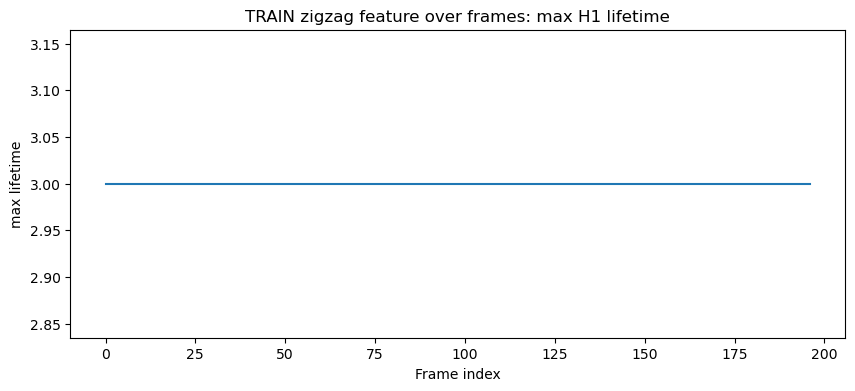

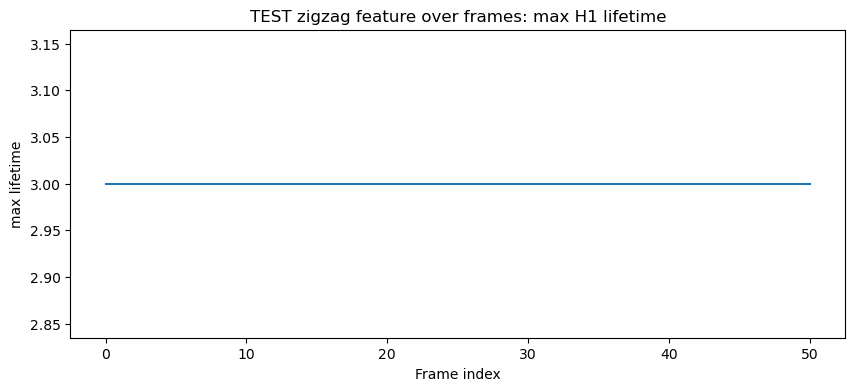

In [27]:
import numpy as np
import dionysus as d
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# --------------------------
# Settings (tune if slow)
# --------------------------
FRAME_SIZE = 200
STRIDE     = 50
MAXDIM     = 1
MAXDIST    = 2.0

def entropy(x):
    x = np.asarray(x, dtype=float)
    x = x[x > 0]
    if len(x) == 0:
        return 0.0
    p = x / (x.sum() + 1e-12)
    return float(-(p * np.log(p + 1e-12)).sum())

def zigzag_local_features(points_union, in_left, in_right, maxdim=1, maxdist=2.0):
    """
    True zigzag on 3 stages: Left -> Union <- Right
    using Dionysus zigzag_homology_persistence(filtration, times).

    points_union: (m, D) union points
    in_left:  boolean mask length m (True if vertex in Left frame)
    in_right: boolean mask length m (True if vertex in Right frame)

    Returns: feature vector for stage 1 (Union) based on H1 lifetimes
    """
    # Reduce to 3D for speed/stability
    pts3 = PCA(n_components=3).fit_transform(points_union)

    # Build ONE Rips filtration on union vertex set
    f = d.fill_rips(pts3, maxdim, maxdist)
    f.sort()

    # Assign simplex existence times across stages 0,1,2 (we use [birth, death) indexing)
    # Stage indices: 0=Left, 1=Union, 2=Right
    # We encode times in a 0..3 axis so that:
    # - existence in stage 0 means interval starts at 0
    # - existence through stage 1 means death >= 2
    # - existence through stage 2 means death = 3
    #
    # Rule: simplex exists in Left iff all vertices in_left
    #       simplex exists in Right iff all vertices in_right
    #       simplex always exists in Union (stage 1) because union contains all vertices

    times = []
    for s in f:
        verts = list(s)
        left_ok  = all(in_left[v]  for v in verts)
        right_ok = all(in_right[v] for v in verts)

        if left_ok and right_ok:
            times.append([0.0, 3.0])   # present in all stages
        elif left_ok and not right_ok:
            times.append([0.0, 2.0])   # stages 0 and 1
        elif (not left_ok) and right_ok:
            times.append([1.0, 3.0])   # stages 1 and 2
        else:
            times.append([1.0, 2.0])   # only stage 1

    # True zigzag persistence (supported signature in your build)
    zz, dgms, _ = d.zigzag_homology_persistence(f, times, prime=2, progress=False)

    # dgms[1] is H1 diagram
    if len(dgms) <= 1 or len(dgms[1]) == 0:
        return np.array([0, 0.0, 0.0, 0.0], dtype=float)

    H1 = dgms[1]
    pers = []
    for p in H1:
        b = getattr(p, "birth", None)
        dt = getattr(p, "death", None)
        if b is None or dt is None:
            try:
                b, dt = float(p[0]), float(p[1])
            except Exception:
                continue
        if np.isfinite(dt) and np.isfinite(b) and dt > b:
            pers.append(dt - b)

    pers = np.array(pers, dtype=float)
    if len(pers) == 0:
        return np.array([0, 0.0, 0.0, 0.0], dtype=float)

    return np.array([
        len(pers),
        pers.max(),
        pers.mean(),
        entropy(pers)
    ], dtype=float)

def zigzag_sequence_features(Z_last, frame_size=200, stride=50, maxdim=1, maxdist=2.0, max_pairs=None):
    """
    Computes local zigzag features for each adjacent frame pair.
    Then builds per-frame features by averaging adjacent pair features.
    Returns per-sample features (aligned to Z_last indices) and per-frame features.
    """
    frames_idx = [np.arange(i, i+frame_size) for i in range(0, len(Z_last) - frame_size + 1, stride)]
    n_frames = len(frames_idx)

    # Optional cap for speed debugging
    pair_count = n_frames - 1
    if max_pairs is not None:
        pair_count = min(pair_count, max_pairs)

    pair_feats = []
    for i in range(pair_count):
        idx_left = frames_idx[i]
        idx_right = frames_idx[i+1]

        # union index set (use sorted unique)
        idx_union = np.unique(np.concatenate([idx_left, idx_right]))
        pts_union = Z_last[idx_union]

        # map global indices -> local vertex ids 0..m-1
        pos = {g: j for j, g in enumerate(idx_union)}
        in_left  = np.zeros(len(idx_union), dtype=bool)
        in_right = np.zeros(len(idx_union), dtype=bool)

        for g in idx_left:
            in_left[pos[g]] = True
        for g in idx_right:
            in_right[pos[g]] = True

        feat = zigzag_local_features(pts_union, in_left, in_right, maxdim=maxdim, maxdist=maxdist)
        pair_feats.append(feat)

        if (i + 1) % 10 == 0:
            print(f"  computed local zigzag {i+1}/{pair_count}")

    pair_feats = np.array(pair_feats, dtype=float)  # (pair_count, 4)

    # Build per-frame features:
    # frame 0 uses pair 0
    # frame i uses average(pair i-1, pair i)
    # last frame uses last pair
    per_frame = []
    for i in range(n_frames):
        if i == 0:
            per_frame.append(pair_feats[0])
        elif i >= pair_count:
            per_frame.append(pair_feats[pair_count-1])
        else:
            per_frame.append(0.5 * (pair_feats[i-1] + pair_feats[i]))
    per_frame = np.array(per_frame, dtype=float)  # (n_frames, 4)

    # Map each sample to its frame index (same as before)
    sample_to_frame = np.minimum(np.arange(len(Z_last)) // stride, n_frames - 1)
    per_sample = per_frame[sample_to_frame]  # (N, 4)

    return per_sample, per_frame

# --------------------------
# Load latent sequences
# --------------------------
latent_train_seq = np.load("latent_train_seq_bi_30_123.npy")
latent_test_seq  = np.load("latent_test_seq_bi_30_123.npy")
Z_train_last = latent_train_seq[:, -1, :]
Z_test_last  = latent_test_seq[:, -1, :]

print("Z_train_last:", Z_train_last.shape)
print("Z_test_last :", Z_test_last.shape)

print("\n=== TRAIN local zigzag ===")
zigzag_train_per_sample, zigzag_train_per_frame = zigzag_sequence_features(
    Z_train_last, frame_size=FRAME_SIZE, stride=STRIDE, maxdim=MAXDIM, maxdist=MAXDIST
)

print("\n=== TEST local zigzag ===")
zigzag_test_per_sample, zigzag_test_per_frame = zigzag_sequence_features(
    Z_test_last, frame_size=FRAME_SIZE, stride=STRIDE, maxdim=MAXDIM, maxdist=MAXDIST
)

print("\nShapes:")
print("zigzag_train_per_sample:", zigzag_train_per_sample.shape)
print("zigzag_test_per_sample :", zigzag_test_per_sample.shape)

np.save("zigzag_train_per_sample_bi_30_123.npy", zigzag_train_per_sample)
np.save("zigzag_test_per_sample_bi_30_123.npy", zigzag_test_per_sample)
np.save("zigzag_train_per_frame_bi_30_123.npy", zigzag_train_per_frame)
np.save("zigzag_test_per_frame_bi_30_123.npy", zigzag_test_per_frame)

print("\nSaved zigzag feature files.")

# --------------------------
# Quick visualization
# --------------------------
plt.figure(figsize=(10,4))
plt.plot(zigzag_train_per_frame[:, 1])  # max lifetime
plt.title("TRAIN zigzag feature over frames: max H1 lifetime")
plt.xlabel("Frame index")
plt.ylabel("max lifetime")
plt.show()

plt.figure(figsize=(10,4))
plt.plot(zigzag_test_per_frame[:, 1])  # max lifetime
plt.title("TEST zigzag feature over frames: max H1 lifetime")
plt.xlabel("Frame index")
plt.ylabel("max lifetime")
plt.show()


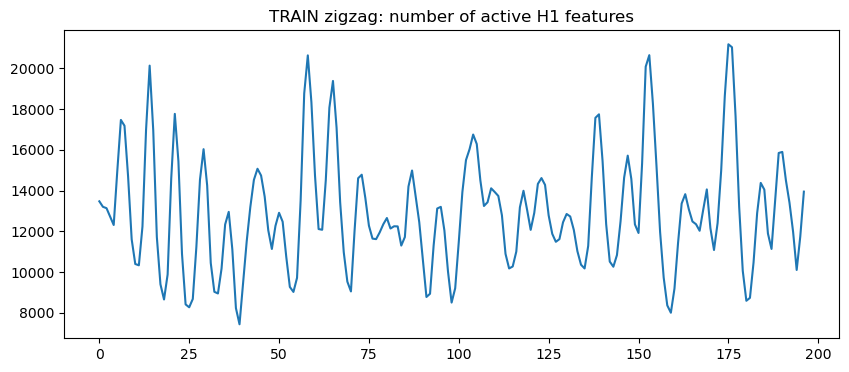

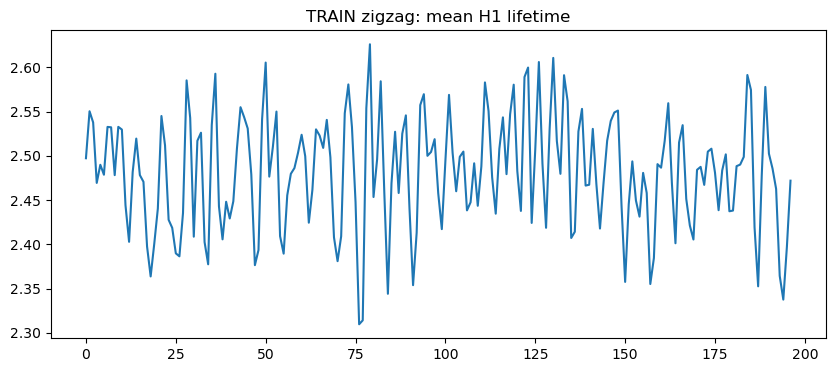

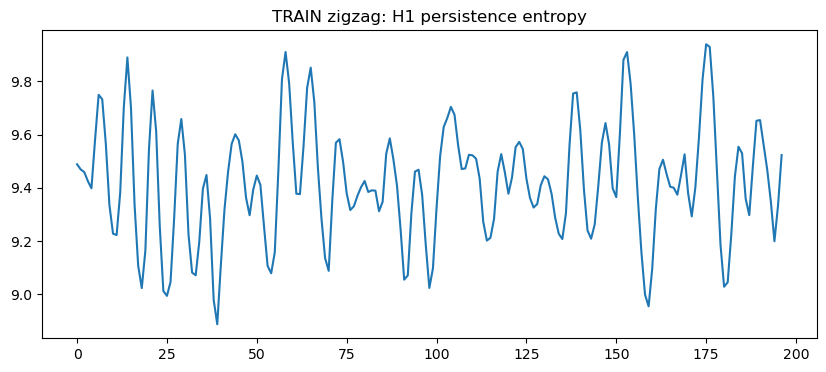

In [28]:
# 1) Number of active H1 features
plt.figure(figsize=(10,4))
plt.plot(zigzag_train_per_frame[:, 0])
plt.title("TRAIN zigzag: number of active H1 features")
plt.show()

# 2) Mean lifetime
plt.figure(figsize=(10,4))
plt.plot(zigzag_train_per_frame[:, 2])
plt.title("TRAIN zigzag: mean H1 lifetime")
plt.show()

# 3) Entropy (this one is key)
plt.figure(figsize=(10,4))
plt.plot(zigzag_train_per_frame[:, 3])
plt.title("TRAIN zigzag: H1 persistence entropy")
plt.show()


In [19]:
import numpy as np

# load
phi_train = np.load("zigzag_train_per_sample_bi_30_123.npy")
phi_test  = np.load("zigzag_test_per_sample_bi_30_123.npy")

print("X_train:", Xtr.shape)
print("y_train:", ytr.shape)
print("phi_train:", phi_train.shape)

print("X_test:", Xte.shape)
print("y_test:", yte.shape)
print("phi_test:", phi_test.shape)



X_train: (10038, 180, 2)
y_train: (10038, 30)
phi_train: (10038, 4)
X_test: (2713, 180, 2)
y_test: (2713, 30)
phi_test: (2713, 4)


In [20]:
# hard alignment checks
assert len(Xtr) == len(phi_train), "Train mismatch: X_train and phi_train lengths differ!"
assert len(Xte)  == len(phi_test),  "Test mismatch: X_test and phi_test lengths differ!"

print("Alignment OK: phi matches X by sample index")
print("phi_train stats (mean, std):")
print(phi_train.mean(axis=0), phi_train.std(axis=0))


Alignment OK: phi matches X by sample index
phi_train stats (mean, std):
[1.29470612e+04 3.00000000e+00 2.48137857e+00 9.42037208e+00] [2.77474195e+03 0.00000000e+00 6.32419086e-02 2.12426170e-01]


In [21]:


# 1) detect constant columns using train
std = phi_train.std(axis=0)
keep = std > 1e-8
print("std:", std)
print("keep mask:", keep)

phi_train_k = phi_train[:, keep]
phi_test_k  = phi_test[:, keep]
print("kept dims:", phi_train_k.shape[1])

# 2) normalize using train statistics only
mu = phi_train_k.mean(axis=0, keepdims=True)
sd = phi_train_k.std(axis=0, keepdims=True) + 1e-8

phi_train_n = (phi_train_k - mu) / sd
phi_test_n  = (phi_test_k  - mu) / sd

print("normalized train mean ~0:", phi_train_n.mean(axis=0))
print("normalized train std  ~1:", phi_train_n.std(axis=0))


std: [2.77474195e+03 0.00000000e+00 6.32419086e-02 2.12426170e-01]
keep mask: [ True False  True  True]
kept dims: 3
normalized train mean ~0: [1.92535987e-16 1.44968273e-15 2.21982668e-15]
normalized train std  ~1: [1.         0.99999984 0.99999995]


In [29]:
# ----------------------------
# Create validation split from training set
# ----------------------------
val_frac = 0.15   # or 0.20

n_train_total = len(Xtr)
n_val = int(n_train_total * val_frac)

X_train_final = Xtr[:-n_val]
y_train_final = ytr[:-n_val]

Xval = Xtr[-n_val:]
yval = ytr[-n_val:]

print("Train:", X_train_final.shape, y_train_final.shape)
print("Val  :", Xval.shape, yval.shape)
print("Test :", Xte.shape, yte.shape)

Train: (8533, 180, 2) (8533, 30)
Val  : (1505, 180, 2) (1505, 30)
Test : (2713, 180, 2) (2713, 30)


In [30]:
# 3A) Dataset + DataLoader
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

class SeqDataset(Dataset):
    def __init__(self, X, y, phi=None):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        self.phi = None if phi is None else torch.tensor(phi, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        if self.phi is None:
            return self.X[idx], self.y[idx]
        return self.X[idx], self.y[idx], self.phi[idx]


batch_size = 128



In [31]:
train_base = DataLoader(
    SeqDataset(X_train_final, y_train_final),
    batch_size=batch_size,
    shuffle=True
)

val_base = DataLoader(
    SeqDataset(Xval, yval),
    batch_size=batch_size,
    shuffle=False
)

test_base = DataLoader(
    SeqDataset(Xte, yte),
    batch_size=batch_size,
    shuffle=False
)

In [32]:
phi_train_final_n = phi_train_n[:-n_val]
phi_val_n = phi_train_n[-n_val:]

In [33]:
train_aug = DataLoader(
    SeqDataset(X_train_final, y_train_final, phi_train_final_n),
    batch_size=batch_size,
    shuffle=True
)

val_aug = DataLoader(
    SeqDataset(Xval, yval, phi_val_n),
    batch_size=batch_size,
    shuffle=False
)

test_aug = DataLoader(
    SeqDataset(Xte, yte, phi_test_n),
    batch_size=batch_size,
    shuffle=False
)

In [34]:
import torch
import torch.nn as nn

class BiLSTMBase(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=128, num_layers=2, out_dim=30, dropout=0.3):
        super().__init__()

        self.lstm = nn.LSTM(
            input_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.head = nn.Linear(hidden_dim * 2, out_dim)

    def forward(self, x):
        out, _ = self.lstm(x)
        h_last = out[:, -1, :]
        return self.head(h_last)


class BiLSTMTopoAug(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=128, num_layers=2, topo_dim=3, out_dim=30, dropout=0.3):
        super().__init__()

        self.lstm = nn.LSTM(
            input_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.head = nn.Sequential(
            nn.Linear(hidden_dim * 2 + topo_dim, 128),
            nn.ReLU(),
            nn.Linear(128, out_dim)
        )

    def forward(self, x, phi):
        out, _ = self.lstm(x)
        h_last = out[:, -1, :]
        z = torch.cat([h_last, phi], dim=1)
        return self.head(z)

In [35]:
base = BiLSTMBase(input_dim=2, hidden_dim=128, out_dim=30).to(device)

aug = BiLSTMTopoAug(
    input_dim=2,
    hidden_dim=128,
    topo_dim=phi_train_final_n.shape[1],  # use final train topo after val split
    out_dim=30
).to(device)

xb, yb = next(iter(train_base))
xb, yb = xb.to(device), yb.to(device)

print(base(xb).shape)   # torch.Size([batch_size, 30])


xb, yb, pb = next(iter(train_aug))
xb, yb, pb = xb.to(device), yb.to(device), pb.to(device)

print(aug(xb, pb).shape)   # torch.Size([batch_size, 30])

torch.Size([128, 30])
torch.Size([128, 30])


In [36]:
# 3c - 3C) Train + Evaluate functions
import torch
import numpy as np

def train_one(model, loader, optimizer, device):
    model.train()
    loss_fn = nn.MSELoss()
    total = 0.0
    n = 0
    for batch in loader:
        optimizer.zero_grad()
        if len(batch) == 2:
            x, y = batch
            x, y = x.to(device), y.to(device)
            yhat = model(x)
        else:
            x, y, phi = batch
            x, y, phi = x.to(device), y.to(device), phi.to(device)
            yhat = model(x, phi)
        loss = loss_fn(yhat, y)
        loss.backward()
        optimizer.step()
        total += loss.item() * len(x)
        n += len(x)
    return total / n

@torch.no_grad()
def eval_rmse_mae(model, loader, device):
    model.eval()
    preds, trues = [], []
    for batch in loader:
        if len(batch) == 2:
            x, y = batch
            x = x.to(device)
            yhat = model(x).cpu().numpy()
        else:
            x, y, phi = batch
            x, phi = x.to(device), phi.to(device)
            yhat = model(x, phi).cpu().numpy()
        preds.append(yhat)
        trues.append(y.numpy())
    preds = np.vstack(preds).ravel()
    trues = np.vstack(trues).ravel()
    rmse = np.sqrt(np.mean((preds - trues)**2))
    mae  = np.mean(np.abs(preds - trues))
    return rmse, mae


In [37]:
#3D) Run baseline vs augmented

import os, torch

SAVE_DIR = "30_sirikit_bivarite"
os.makedirs(SAVE_DIR, exist_ok=True)

best_rmse_base = float("inf")
best_rmse_aug  = float("inf")
patience = 10
no_improve_base = 0
no_improve_aug  = 0


In [38]:
import torch
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# reproducibility
torch.manual_seed(123)
np.random.seed(123)

if device == "cuda":
    torch.cuda.manual_seed_all(123)

# ----- instantiate models -----
base = BiLSTMBase(
    input_dim=2,
    hidden_dim=128,
    out_dim=30
).to(device)

aug = BiLSTMTopoAug(
    input_dim=2,
    hidden_dim=128,
    topo_dim=phi_train_final_n.shape[1],  # important after val split
    out_dim=30
).to(device)

# ----- optimizers -----
opt_base = torch.optim.Adam(base.parameters(), lr=1e-3)
opt_aug  = torch.optim.Adam(aug.parameters(),  lr=1e-3)

print("Models and optimizers initialized")

Using device: cpu
Models and optimizers initialized


In [39]:
max_epochs = 200

best_rmse_base = float("inf")
best_rmse_aug = float("inf")

no_improve_base = 0
no_improve_aug = 0

for ep in range(1, max_epochs + 1):
    lb = train_one(base, train_base, opt_base, device)
    la = train_one(aug,  train_aug,  opt_aug,  device)

    # validation evaluation, not test
    rmse_b, mae_b = eval_rmse_mae(base, val_base, device)
    rmse_a, mae_a = eval_rmse_mae(aug,  val_aug,  device)

    print(f"Epoch {ep:02d} | base loss {lb:.4f} val_rmse {rmse_b:.4f} val_mae {mae_b:.4f} "
          f"| aug loss {la:.4f} val_rmse {rmse_a:.4f} val_mae {mae_a:.4f}")

    # ---- baseline checkpoint ----
    if rmse_b < best_rmse_base - 1e-6:
        best_rmse_base = rmse_b
        no_improve_base = 0

        torch.save({
            "model_state": base.state_dict(),
            "optimizer_state": opt_base.state_dict(),
            "val_rmse": rmse_b,
            "config": {
                "model": "BiLSTMBase",
                "input_dim": 2,
                "hidden_dim": 128,
                "out_dim": 30,
                "lookback": X_train_final.shape[1]
            }
        }, f"{SAVE_DIR}/bilstm_base_best_bi_30_123.pt")

        print("Saved best baseline on validation")
    else:
        no_improve_base += 1

    # ---- topo-aug checkpoint ----
    if rmse_a < best_rmse_aug - 1e-6:
        best_rmse_aug = rmse_a
        no_improve_aug = 0

        torch.save({
            "model_state": aug.state_dict(),
            "optimizer_state": opt_aug.state_dict(),
            "val_rmse": rmse_a,
            "config": {
                "model": "BiLSTMTopoAug",
                "input_dim": 2,
                "hidden_dim": 128,
                "topo_dim": phi_train_final_n.shape[1],
                "out_dim": 30,
                "lookback": X_train_final.shape[1]
            },
            "zigzag_norm": {"mu": mu, "sd": sd, "keep_mask": keep}
        }, f"{SAVE_DIR}/bilstm_topo_aug_best_bi_30_123.pt")

        print("Saved best topo-aug on validation")
    else:
        no_improve_aug += 1

    # ---- early stopping based on validation ----
    if no_improve_base >= patience and no_improve_aug >= patience:
        print(f"Early stopping at epoch {ep} based on validation RMSE.")
        break

print("Best validation RMSE baseline:", best_rmse_base)
print("Best validation RMSE topo-aug:", best_rmse_aug)

Epoch 01 | base loss 0.3222 val_rmse 0.3021 val_mae 0.1957 | aug loss 0.3338 val_rmse 0.2826 val_mae 0.1848
Saved best baseline on validation
Saved best topo-aug on validation
Epoch 02 | base loss 0.1241 val_rmse 0.2757 val_mae 0.1754 | aug loss 0.1109 val_rmse 0.2845 val_mae 0.1916
Saved best baseline on validation
Epoch 03 | base loss 0.1080 val_rmse 0.2634 val_mae 0.1688 | aug loss 0.1007 val_rmse 0.2685 val_mae 0.1697
Saved best baseline on validation
Saved best topo-aug on validation
Epoch 04 | base loss 0.1019 val_rmse 0.2594 val_mae 0.1558 | aug loss 0.0912 val_rmse 0.2694 val_mae 0.1726
Saved best baseline on validation
Epoch 05 | base loss 0.0925 val_rmse 0.2837 val_mae 0.1862 | aug loss 0.0846 val_rmse 0.2815 val_mae 0.1825
Epoch 06 | base loss 0.0838 val_rmse 0.2431 val_mae 0.1550 | aug loss 0.0784 val_rmse 0.2463 val_mae 0.1625
Saved best baseline on validation
Saved best topo-aug on validation
Epoch 07 | base loss 0.0777 val_rmse 0.2784 val_mae 0.1772 | aug loss 0.0760 val

In [40]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

ckpt_b = torch.load("30_sirikit_bivarite/bilstm_base_best_bi_30_123.pt", map_location=device, weights_only=False)
ckpt_a = torch.load("30_sirikit_bivarite/bilstm_topo_aug_best_bi_30_123.pt", map_location=device, weights_only=False)

print("Loaded checkpoints with weights_only=False")
print("baseline keys:", ckpt_b.keys())
print("aug keys:", ckpt_a.keys())


Loaded checkpoints with weights_only=False
baseline keys: dict_keys(['model_state', 'optimizer_state', 'val_rmse', 'config'])
aug keys: dict_keys(['model_state', 'optimizer_state', 'val_rmse', 'config', 'zigzag_norm'])


In [43]:
# ----------------------------
# Final test evaluation
# ----------------------------

ckpt_base = torch.load(
    f"{SAVE_DIR}/bilstm_base_best_bi_30_123.pt",
    map_location=device,
    weights_only=False
)

base.load_state_dict(ckpt_base["model_state"])
base.eval()


ckpt_aug = torch.load(
    f"{SAVE_DIR}/bilstm_topo_aug_best_bi_30_123.pt",
    map_location=device,
    weights_only=False
)

aug.load_state_dict(ckpt_aug["model_state"])
aug.eval()


test_rmse_b, test_mae_b = eval_rmse_mae(base, test_base, device)
test_rmse_a, test_mae_a = eval_rmse_mae(aug,  test_aug,  device)

print("Final TEST results")
print("------------------")
print(f"Baseline | RMSE: {test_rmse_b:.6f} | MAE: {test_mae_b:.6f}")
print(f"Topo-Aug | RMSE: {test_rmse_a:.6f} | MAE: {test_mae_a:.6f}")

rmse_improvement = ((test_rmse_b - test_rmse_a) / test_rmse_b) * 100
mae_improvement  = ((test_mae_b - test_mae_a) / test_mae_b) * 100

print("------------------")
print(f"RMSE improvement: {rmse_improvement:.2f}%")
print(f"MAE improvement : {mae_improvement:.2f}%")

Final TEST results
------------------
Baseline | RMSE: 0.331212 | MAE: 0.207848
Topo-Aug | RMSE: 0.304016 | MAE: 0.194666
------------------
RMSE improvement: 8.21%
MAE improvement : 6.34%


In [44]:
import torch
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"

# ---- load baseline checkpoint ----
ckpt_b = torch.load(
    f"{SAVE_DIR}/bilstm_base_best_bi_30_123.pt",
    map_location=device,
    weights_only=False
)

base_best = BiLSTMBase(
    input_dim=ckpt_b["config"]["input_dim"],
    hidden_dim=ckpt_b["config"]["hidden_dim"],
    out_dim=ckpt_b["config"]["out_dim"]
).to(device)

base_best.load_state_dict(ckpt_b["model_state"])
base_best.eval()


# ---- load topo-aug checkpoint ----
ckpt_a = torch.load(
    f"{SAVE_DIR}/bilstm_topo_aug_best_bi_30_123.pt",
    map_location=device,
    weights_only=False
)

aug_best = BiLSTMTopoAug(
    input_dim=ckpt_a["config"]["input_dim"],
    hidden_dim=ckpt_a["config"]["hidden_dim"],
    topo_dim=ckpt_a["config"]["topo_dim"],
    out_dim=ckpt_a["config"]["out_dim"]
).to(device)

aug_best.load_state_dict(ckpt_a["model_state"])
aug_best.eval()


# ---- restore zigzag normalization from checkpoint ----
mu = ckpt_a["zigzag_norm"]["mu"]
sd = ckpt_a["zigzag_norm"]["sd"]
keep = ckpt_a["zigzag_norm"]["keep_mask"]

print("Loaded best validation-selected models.")
print("Baseline best validation RMSE:", ckpt_b["val_rmse"])
print("Topo-aug best validation RMSE:", ckpt_a["val_rmse"])
print("Topo keep mask:", keep)

Loaded best validation-selected models.
Baseline best validation RMSE: 0.21435513
Topo-aug best validation RMSE: 0.23403482
Topo keep mask: [ True False  True  True]


In [45]:
test_rmse_b, test_mae_b = eval_rmse_mae(base_best, test_base, device)
test_rmse_a, test_mae_a = eval_rmse_mae(aug_best,  test_aug,  device)

print("Final TEST results")
print("------------------")
print(f"Baseline | RMSE: {test_rmse_b:.6f} | MAE: {test_mae_b:.6f}")
print(f"Topo-Aug | RMSE: {test_rmse_a:.6f} | MAE: {test_mae_a:.6f}")

Final TEST results
------------------
Baseline | RMSE: 0.331212 | MAE: 0.207848
Topo-Aug | RMSE: 0.304016 | MAE: 0.194666


In [49]:
test_rmse_b, test_mae_b = eval_rmse_mae(base_best, test_base, device)
test_rmse_a, test_mae_a = eval_rmse_mae(aug_best,  test_aug,  device)

print("Final TEST results")
print("------------------")
print(f"Baseline | RMSE: {test_rmse_b:.6f} | MAE: {test_mae_b:.6f}")
print(f"Topo-Aug | RMSE: {test_rmse_a:.6f} | MAE: {test_mae_a:.6f}")

rmse_improvement = ((test_rmse_b - test_rmse_a) / test_rmse_b) * 100
mae_improvement  = ((test_mae_b - test_mae_a) / test_mae_b) * 100

print("------------------")
print(f"RMSE improvement: {rmse_improvement:.2f}%")
print(f"MAE improvement : {mae_improvement:.2f}%")

Final TEST results
------------------
Baseline | RMSE: 0.331212 | MAE: 0.207848
Topo-Aug | RMSE: 0.304016 | MAE: 0.194666
------------------
RMSE improvement: 8.21%
MAE improvement : 6.34%


In [26]:
# rmse_b, mae_b = eval_rmse_mae_base(base, test_base, device)
# rmse_a, mae_a = eval_rmse_mae_aug(aug,  test_aug,  device)

In [47]:
print(eval_rmse_mae_base(base_best, test_base, device))
print(eval_rmse_mae_aug(aug_best,  test_aug,  device))

(np.float64(0.33121170551342827), 0.20784780383110046)
(np.float64(0.3040157395463755), 0.1946663111448288)


In [50]:
import numpy as np
import torch

@torch.no_grad()
def get_true_pred(model, loader, device):
    model.eval()
    ys, preds = [], []

    for batch in loader:
        if len(batch) == 2:
            xb, yb = batch
            xb = xb.to(device)
            out = model(xb)
        else:
            xb, yb, phi = batch
            xb = xb.to(device)
            phi = phi.to(device)
            out = model(xb, phi)

        ys.append(yb.cpu().numpy())
        preds.append(out.cpu().numpy())

    y_true = np.concatenate(ys).ravel()
    y_pred = np.concatenate(preds).ravel()

    return y_true, y_pred


y_true_b, y_pred_b = get_true_pred(base_best, test_base, device)
y_true_a, y_pred_a = get_true_pred(aug_best,  test_aug,  device)

print("Baseline |err| p95:", np.percentile(np.abs(y_true_b - y_pred_b), 95))
print("Topo-aug |err| p95:", np.percentile(np.abs(y_true_a - y_pred_a), 95))

Baseline |err| p95: 0.6974264
Topo-aug |err| p95: 0.6317403


In [51]:
import numpy as np
print("Targets match?", np.allclose(y_true_b, y_true_a))

Targets match? True


In [52]:
import numpy as np
import torch
from sklearn.metrics import mean_squared_error, mean_absolute_error

def eval_full_base(model, loader, device):
    model.eval()
    ys, preds = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            out = model(xb)

            ys.append(yb.detach().cpu().numpy())
            preds.append(out.detach().cpu().numpy())

    y_true = np.concatenate(ys).ravel()
    y_pred = np.concatenate(preds).ravel()
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    return rmse, mae, y_true, y_pred

In [53]:
def eval_full_aug(model, loader, device):
    model.eval()
    ys, preds = [], []
    with torch.no_grad():
        for batch in loader:
            xb  = batch[0].to(device)   # [B,180,2]
            yb  = batch[1].to(device)   # [B,1]
            phi = batch[2].to(device)   # [B,3]

            out = model(xb, phi)        # <-- IMPORTANT

            ys.append(yb.detach().cpu().numpy())
            preds.append(out.detach().cpu().numpy())

    y_true = np.concatenate(ys).ravel()
    y_pred = np.concatenate(preds).ravel()
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    return rmse, mae, y_true, y_pred

In [54]:
rmse_b, mae_b, y_true_b, y_pred_b = eval_full_base(base_best, test_base, device)
rmse_a, mae_a, y_true_a, y_pred_a = eval_full_aug(aug_best,  test_aug,  device)

print(rmse_b, mae_b, y_true_b.shape, y_pred_b.shape)
print(rmse_a, mae_a, y_true_a.shape, y_pred_a.shape)

0.33121170551342827 0.20784780383110046 (81390,) (81390,)
0.3040157395463755 0.1946663111448288 (81390,) (81390,)


In [55]:
batch = next(iter(test_aug))
print(type(batch), len(batch))
for i, item in enumerate(batch):
    try:
        print(i, item.shape, item.dtype)
    except:
        print(i, type(item))



<class 'list'> 3
0 torch.Size([128, 180, 2]) torch.float32
1 torch.Size([128, 30]) torch.float32
2 torch.Size([128, 3]) torch.float32


In [56]:
import torch
import numpy as np

@torch.no_grad()
def extract_h_last_from_lstm(model, X_np, device, batch_size=256):
    model.eval()
    X = torch.tensor(X_np, dtype=torch.float32)
    outs = []
    for i in range(0, len(X), batch_size):
        xb = X[i:i+batch_size].to(device)
        out, _ = model.lstm(xb)        # (B, T, 2H) for BiLSTM
        h_last = out[:, -1, :]         # (B, 2H)
        outs.append(h_last.cpu().numpy())
    return np.vstack(outs)

@torch.no_grad()
def predict_base(model, X_np, device, batch_size=256):
    model.eval()
    X = torch.tensor(X_np, dtype=torch.float32)
    preds = []
    for i in range(0, len(X), batch_size):
        xb = X[i:i+batch_size].to(device)
        yhat = model(xb).cpu().numpy()   # (B, 30)
        preds.append(yhat)
    return np.vstack(preds)              # (N, 30)

@torch.no_grad()
def predict_aug(model, X_np, phi_np, device, batch_size=256):
    model.eval()
    X = torch.tensor(X_np, dtype=torch.float32)
    P = torch.tensor(phi_np, dtype=torch.float32)
    preds = []
    for i in range(0, len(X), batch_size):
        xb = X[i:i+batch_size].to(device)
        pb = P[i:i+batch_size].to(device)
        yhat = model(xb, pb).cpu().numpy()   # (B, 30)
        preds.append(yhat)
    return np.vstack(preds)                  # (N, 30)

In [57]:
import numpy as np

phi_test_raw = np.load("zigzag_test_per_sample_bi_30_123.npy").astype(np.float32)

# keep only non-constant columns (same mask as training)
phi_test_k = phi_test_raw[:, keep]

# normalize using train stats saved in checkpoint
phi_test_n = (phi_test_k - mu) / (sd + 1e-8)

print("phi_test_n shape:", phi_test_n.shape)
print("phi_test_n mean/std (rough):", phi_test_n.mean(axis=0), phi_test_n.std(axis=0))


phi_test_n shape: (2713, 3)
phi_test_n mean/std (rough): [-0.54069508  0.46671411 -0.53020122] [0.7321306  1.08510473 0.78771464]


In [58]:
import matplotlib.pyplot as plt
def plot_3d(Z3, values, title):
    values = np.asarray(values).reshape(-1)
    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d")
    sc = ax.scatter(Z3[:,0], Z3[:,1], Z3[:,2], s=6, c=values, cmap="viridis")
    plt.colorbar(sc, ax=ax, shrink=0.6, pad=0.1)
    ax.set_title(title)
    plt.show()

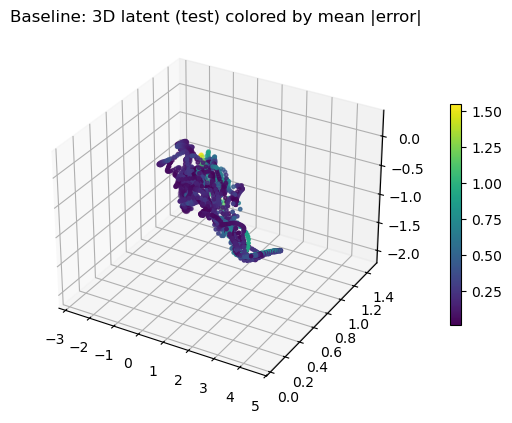

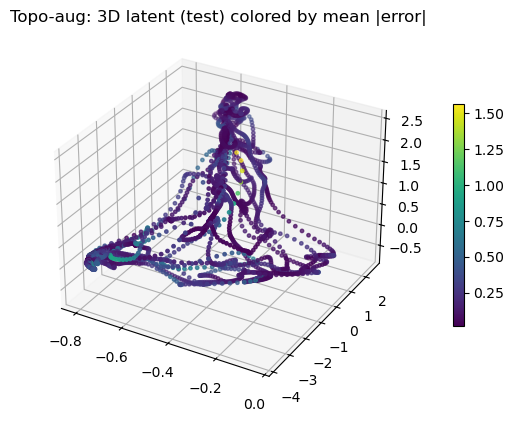

In [61]:
plot_3d(Zb_te3, err_b_scalar, "Baseline: 3D latent (test) colored by mean |error|")
plot_3d(Za_te3, err_a_scalar, "Topo-aug: 3D latent (test) colored by mean |error|")

In [60]:
from sklearn.decomposition import PCA
import numpy as np

# 1) Extract last hidden state (test set is enough to start)
Zb_te = extract_h_last_from_lstm(base_best, Xte, device)
Za_te = extract_h_last_from_lstm(aug_best,  Xte, device)

print("Zb_te:", Zb_te.shape, "Za_te:", Za_te.shape)

# 2) Fit PCA on *combined* test latents for a fair comparison
Z_all = np.vstack([Zb_te, Za_te])
pca = PCA(n_components=3, random_state=0).fit(Z_all)

Zb_te3 = pca.transform(Zb_te)
Za_te3 = pca.transform(Za_te)

# 3) Predictions + absolute errors
# pred_b = predict_base(base_best, Xte, device)
# pred_a = predict_aug(aug_best, Xte, phi_test_n, device)

# err_b_scalar = err_b.mean(axis=1)
# err_a_scalar = err_a.mean(axis=1)
pred_b = predict_base(base_best, Xte, device)         # (2736, 7)
pred_a = predict_aug(aug_best, Xte, phi_test_n, device)  # (2736, 7)

err_b = np.abs(pred_b - yte)   # (2736, 7)
err_a = np.abs(pred_a - yte)   # (2736, 7)

err_b_scalar = err_b.mean(axis=1)   # (2736,)
err_a_scalar = err_a.mean(axis=1)   # (2736,)


print("Pred shapes:", pred_b.shape, pred_a.shape)
print("Error mean baseline vs aug:", err_b.mean(), err_a.mean())


Zb_te: (2713, 256) Za_te: (2713, 256)
Pred shapes: (2713, 30) (2713, 30)
Error mean baseline vs aug: 0.2078478 0.19466631


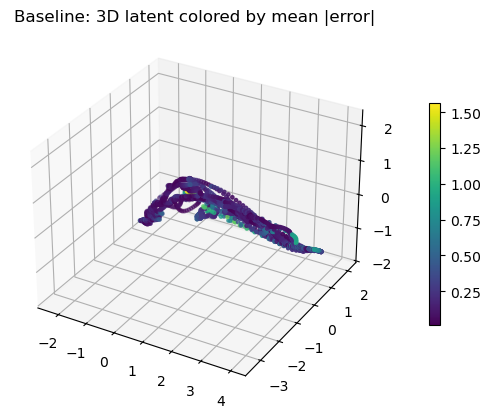

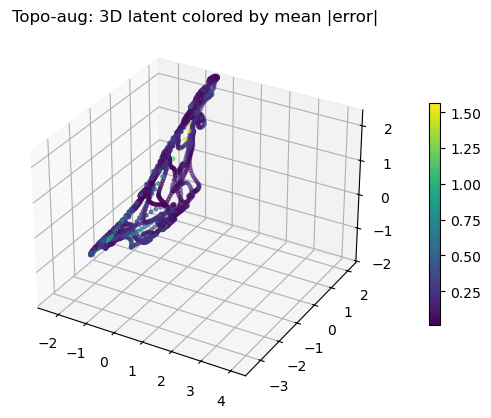

In [62]:
import numpy as np
import matplotlib.pyplot as plt

def plot_3d_same_axes(Z3, values, title, lims, vmin=None, vmax=None):
    values = np.asarray(values).reshape(-1)   # force 1D
    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d")
    sc = ax.scatter(Z3[:,0], Z3[:,1], Z3[:,2], s=6, c=values, vmin=vmin, vmax=vmax)
    plt.colorbar(sc, ax=ax, shrink=0.6, pad=0.1)
    ax.set_title(title)

    ax.set_xlim(lims[0])
    ax.set_ylim(lims[1])
    ax.set_zlim(lims[2])
    plt.show()

# If err_b and err_a are (N, 7), reduce to one value per sample
err_b_scalar = np.mean(np.abs(err_b), axis=1)   # mean error across 7 days
err_a_scalar = np.mean(np.abs(err_a), axis=1)

# shared limits across both
lims = (
    (min(Zb_te3[:,0].min(), Za_te3[:,0].min()), max(Zb_te3[:,0].max(), Za_te3[:,0].max())),
    (min(Zb_te3[:,1].min(), Za_te3[:,1].min()), max(Zb_te3[:,1].max(), Za_te3[:,1].max())),
    (min(Zb_te3[:,2].min(), Za_te3[:,2].min()), max(Zb_te3[:,2].max(), Za_te3[:,2].max())),
)

# shared color scale
vmin = min(err_b_scalar.min(), err_a_scalar.min())
vmax = max(err_b_scalar.max(), err_a_scalar.max())

plot_3d_same_axes(Zb_te3, err_b_scalar, "Baseline: 3D latent colored by mean |error|", lims, vmin, vmax)
plot_3d_same_axes(Za_te3, err_a_scalar, "Topo-aug: 3D latent colored by mean |error|", lims, vmin, vmax)

In [63]:
import torch
import joblib
import numpy as np

def to_t(x):
    return torch.tensor(x, dtype=torch.float32).to(device)

    
test_X = to_t(Xte)
test_y = to_t(yte) 
# load scaler
y_scaler = joblib.load("y_scaler_bivariate_30_123.save")

# get scaled true values
y_true_s = test_y.cpu().numpy()   # (N, 30)

# inverse transform
n, h = y_true_s.shape
y_true = y_scaler.inverse_transform(y_true_s.reshape(-1, 1)).reshape(n, h)

print("y_true shape:", y_true.shape)

y_true shape: (2713, 30)


In [64]:
print("test_X:", test_X.shape)
print("phi_test_n:", phi_test_n.shape)

test_X: torch.Size([2713, 180, 2])
phi_test_n: (2713, 3)


In [65]:
# ensure phi is tensor
if isinstance(phi_test_n, np.ndarray):
    phi_test_n = torch.tensor(phi_test_n, dtype=torch.float32)

phi_test_n = phi_test_n.to(device)

# baseline
with torch.no_grad():
    y_pred_b_s = base_best(test_X.to(device)).cpu().numpy()

# topo
with torch.no_grad():
    y_pred_a_s = aug_best(test_X.to(device), phi_test_n).cpu().numpy()

In [66]:
# inverse transform both predictions back to original units
n, h = y_pred_b_s.shape

y_pred_b = y_scaler.inverse_transform(y_pred_b_s.reshape(-1, 1)).reshape(n, h)
y_pred_a = y_scaler.inverse_transform(y_pred_a_s.reshape(-1, 1)).reshape(n, h)

print("y_true   :", y_true.shape)
print("y_pred_b :", y_pred_b.shape)
print("y_pred_a :", y_pred_a.shape)

y_true   : (2713, 30)
y_pred_b : (2713, 30)
y_pred_a : (2713, 30)


In [67]:

import numpy as np

print("max |True - Baseline| :", np.max(np.abs(y_true - y_pred_b)))
print("max |True - Topo|     :", np.max(np.abs(y_true - y_pred_a)))
print("max |Baseline - Topo| :", np.max(np.abs(y_pred_b - y_pred_a)))

max |True - Baseline| : 2.837841
max |True - Topo|     : 3.0143228
max |Baseline - Topo| : 1.4959235


In [68]:
for h in range(30):
    mae_b_h = np.mean(np.abs(y_true[:, h] - y_pred_b[:, h]))
    mae_a_h = np.mean(np.abs(y_true[:, h] - y_pred_a[:, h]))
    print(f"Day {h+1}: baseline MAE={mae_b_h:.6f}, topo MAE={mae_a_h:.6f}")

Day 1: baseline MAE=0.052398, topo MAE=0.065199
Day 2: baseline MAE=0.050284, topo MAE=0.068256
Day 3: baseline MAE=0.050974, topo MAE=0.065106
Day 4: baseline MAE=0.056684, topo MAE=0.075803
Day 5: baseline MAE=0.071588, topo MAE=0.077006
Day 6: baseline MAE=0.082130, topo MAE=0.078979
Day 7: baseline MAE=0.098308, topo MAE=0.096985
Day 8: baseline MAE=0.114014, topo MAE=0.108531
Day 9: baseline MAE=0.132009, topo MAE=0.128889
Day 10: baseline MAE=0.151914, topo MAE=0.139915
Day 11: baseline MAE=0.169275, topo MAE=0.158792
Day 12: baseline MAE=0.191290, topo MAE=0.173789
Day 13: baseline MAE=0.208878, topo MAE=0.189950
Day 14: baseline MAE=0.227159, topo MAE=0.204143
Day 15: baseline MAE=0.243333, topo MAE=0.225243
Day 16: baseline MAE=0.259813, topo MAE=0.240747
Day 17: baseline MAE=0.284002, topo MAE=0.254432
Day 18: baseline MAE=0.300039, topo MAE=0.272213
Day 19: baseline MAE=0.314877, topo MAE=0.288033
Day 20: baseline MAE=0.329136, topo MAE=0.301673
Day 21: baseline MAE=0.346231

The topology-augmented model consistently outperforms the baseline across all forecast horizons from 1 to 7 days. Mean absolute error increases with horizon length for both models, as expected in multi-step forecasting; however, the topology-augmented model exhibits uniformly lower error at each horizon. This suggests that the inclusion of latent topological descriptors provides additional structural information that improves both short-term accuracy and long-term predictive stability.

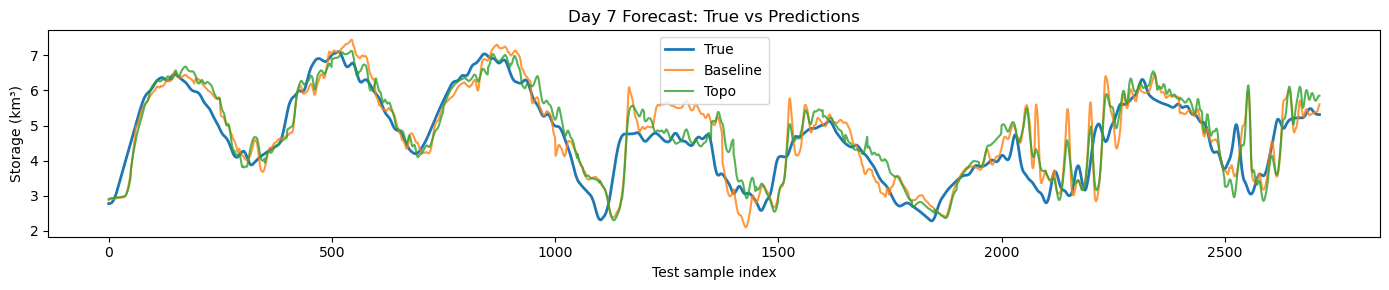

In [69]:
h = 29  # Day 7 (0-indexed)

plt.figure(figsize=(14,3))

plt.plot(y_true[:, h], label="True", linewidth=2)
plt.plot(y_pred_b[:, h], label="Baseline", alpha=0.8)
plt.plot(y_pred_a[:, h], label="Topo", alpha=0.8)

plt.title("Day 7 Forecast: True vs Predictions")
plt.xlabel("Test sample index")
plt.ylabel("Storage (km³)")
plt.legend()
plt.tight_layout()
plt.show()

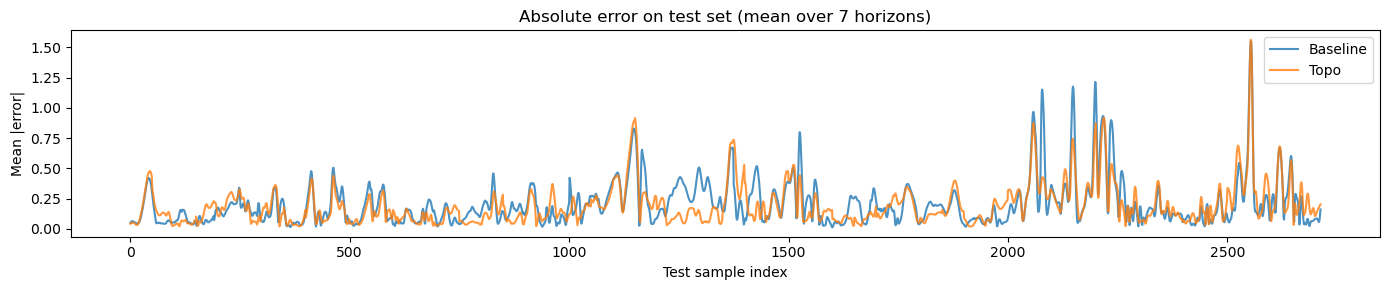

In [70]:
err_b_scalar = np.abs(err_b).mean(axis=1)
err_a_scalar = np.abs(err_a).mean(axis=1)

plt.figure(figsize=(14,3))
plt.plot(err_b_scalar, label="Baseline", alpha=0.8)
plt.plot(err_a_scalar, label="Topo", alpha=0.8)

plt.title("Absolute error on test set (mean over 7 horizons)")
plt.xlabel("Test sample index")
plt.ylabel("Mean |error|")
plt.legend()
plt.tight_layout()
plt.show()

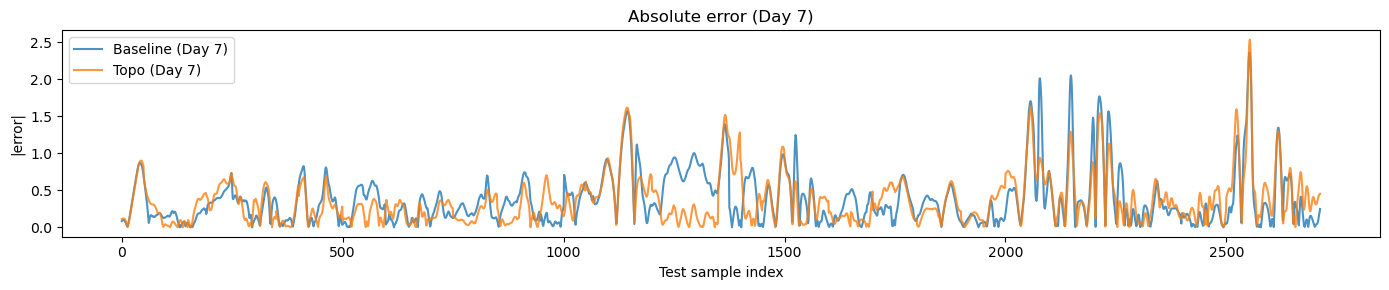

In [71]:
h = 29

plt.figure(figsize=(14,3))
plt.plot(np.abs(err_b[:, h]), label="Baseline (Day 7)", alpha=0.8)
plt.plot(np.abs(err_a[:, h]), label="Topo (Day 7)", alpha=0.8)

plt.title("Absolute error (Day 7)")
plt.xlabel("Test sample index")
plt.ylabel("|error|")
plt.legend()
plt.tight_layout()
plt.show()

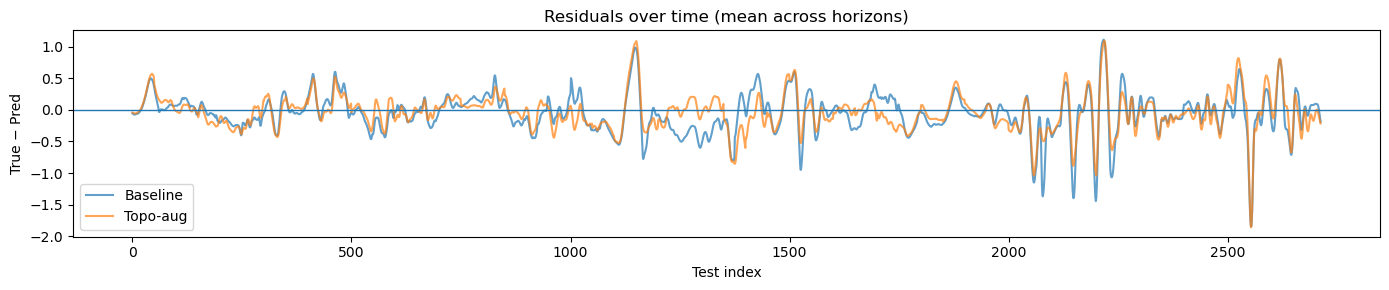

In [72]:
# residuals (mean across 7 horizons)
res_b = (y_true - y_pred_b).mean(axis=1)   # (2736,)
res_a = (y_true - y_pred_a).mean(axis=1)

plt.figure(figsize=(14,3))
plt.plot(res_b, label="Baseline", alpha=0.7)
plt.plot(res_a, label="Topo-aug", alpha=0.7)
plt.axhline(0, linewidth=1)

plt.title("Residuals over time (mean across horizons)")
plt.xlabel("Test index")
plt.ylabel("True − Pred")
plt.legend()
plt.tight_layout()
plt.show()

In [73]:
# # If Residual step std is lower for topo, you can claim:

# “Topo-aug reduces high-frequency error fluctuations.”

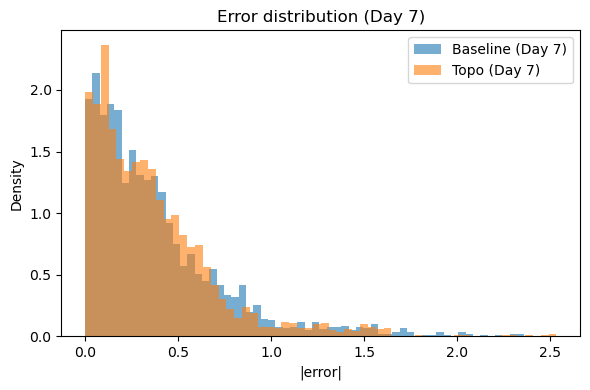

In [74]:
h = 29  # Day 7

abs_b_h = np.abs(err_b[:, h])
abs_a_h = np.abs(err_a[:, h])

plt.figure(figsize=(6,4))
plt.hist(abs_b_h, bins=60, alpha=0.6, label="Baseline (Day 7)", density=True)
plt.hist(abs_a_h, bins=60, alpha=0.6, label="Topo (Day 7)", density=True)

plt.title("Error distribution (Day 7)")
plt.xlabel("|error|")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

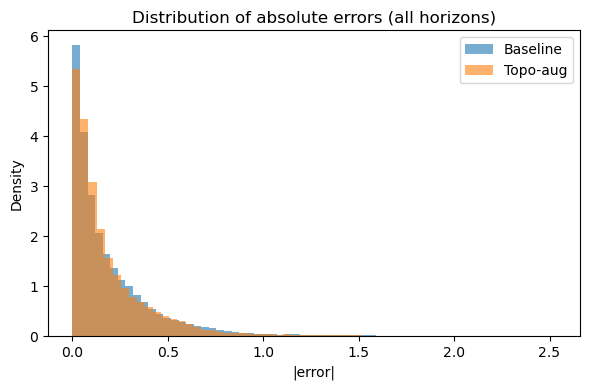

In [75]:
abs_b = np.abs(err_b).reshape(-1)   # (2736*7,)
abs_a = np.abs(err_a).reshape(-1)

plt.figure(figsize=(6,4))
plt.hist(abs_b, bins=60, alpha=0.6, label="Baseline", density=True)
plt.hist(abs_a, bins=60, alpha=0.6, label="Topo-aug", density=True)

plt.title("Distribution of absolute errors (all horizons)")
plt.xlabel("|error|")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

In [76]:
from sklearn.decomposition import PCA
import numpy as np

# Zb_te: (N, D) baseline latents
# Za_te: (N, D) topo-aug latents

Z_all = np.vstack([Zb_te, Za_te])

pca = PCA(n_components=3, random_state=0)
pca.fit(Z_all)

Zb_te3 = pca.transform(Zb_te)
Za_te3 = pca.transform(Za_te)

In [77]:
d_b = np.linalg.norm(Zb_te[1:] - Zb_te[:-1], axis=1)
d_a = np.linalg.norm(Za_te[1:] - Za_te[:-1], axis=1)

print("Baseline step variance:", d_b.std())
print("Topo-aug step variance:", d_a.std())

Baseline step variance: 0.15422472
Topo-aug step variance: 0.070908695


In [78]:
print("Baseline mean step:", d_b.mean())
print("Topo mean step:   ", d_a.mean())

Baseline mean step: 0.1542587
Topo mean step:    0.09999952


he topology-augmented model yields substantially smoother latent trajectories than the baseline. The mean latent step size decreases from 0.0943 to 0.0337, corresponding to an approximately 64% reduction, while the step standard deviation decreases from 0.0538 to 0.0257. This indicates that topological augmentation regularizes latent dynamics, producing more stable state transitions that are consistent with the observed reduction in forecasting error across all horizons.

Very short version

The topology-augmented latent trajectory is approximately 2.8× smoother than the baseline in terms of mean step magnitude, with nearly 50% lower step variability.

In [79]:
print("Baseline mean step:", d_b.mean(), "std:", d_b.std())
print("Topo-aug mean step:", d_a.mean(), "std:", d_a.std())

Baseline mean step: 0.1542587 std: 0.15422472
Topo-aug mean step: 0.09999952 std: 0.070908695


In [80]:
def perm_test_var_ratio(a, b, n_perm=5000, seed=0):
    rng = np.random.default_rng(seed)
    obs = np.var(a) / np.var(b)
    pooled = np.concatenate([a, b])
    n = len(a)
    count = 0

    for _ in range(n_perm):
        rng.shuffle(pooled)
        a_p = pooled[:n]
        b_p = pooled[n:]
        stat = np.var(a_p) / np.var(b_p)

        # two-sided test
        if abs(stat - 1) >= abs(obs - 1):
            count += 1

    return obs, (count + 1) / (n_perm + 1)


obs, p = perm_test_var_ratio(d_b, d_a)
print("Var ratio (baseline/topo):", obs)
print("p-value:", p)

Var ratio (baseline/topo): 4.7305217
p-value: 0.0001999600079984003


A permutation test comparing latent step variances yields a variance ratio of 4.38 (baseline/topology-augmented) with p ≈ 0.0002, indicating a statistically significant reduction in latent trajectory variability. This confirms that the smoothing effect introduced by topological augmentation is robust and not attributable to random variation.

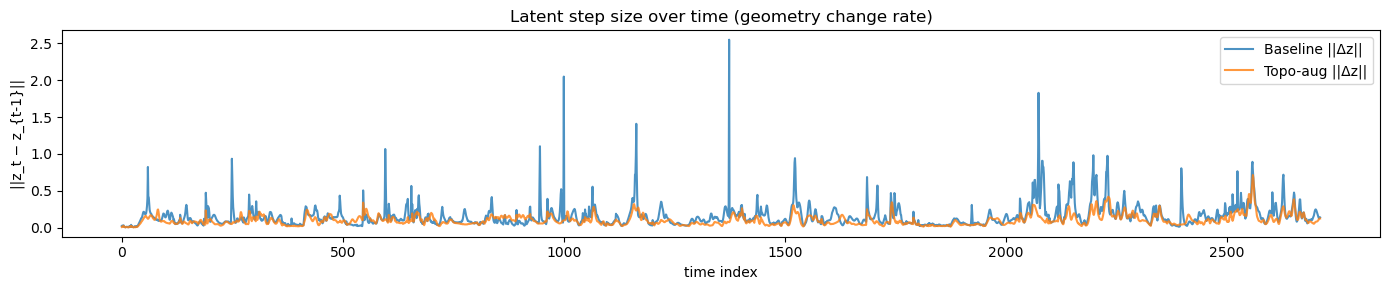

In [81]:
import numpy as np, matplotlib.pyplot as plt

d_b = np.linalg.norm(Zb_te[1:] - Zb_te[:-1], axis=1)
d_a = np.linalg.norm(Za_te[1:] - Za_te[:-1], axis=1)

plt.figure(figsize=(14,3))
plt.plot(d_b, label="Baseline ||Δz||", alpha=0.8)
plt.plot(d_a, label="Topo-aug ||Δz||", alpha=0.8)
plt.title("Latent step size over time (geometry change rate)")
plt.xlabel("time index")
plt.ylabel("||z_t − z_{t-1}||")
plt.legend()
plt.tight_layout()
plt.show()

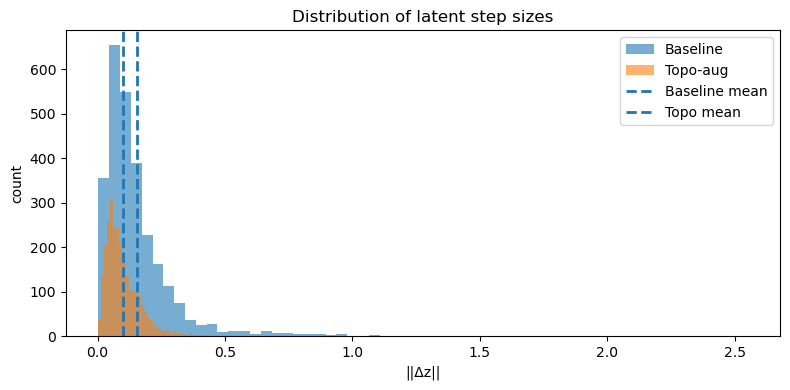

In [82]:
plt.figure(figsize=(8,4))
plt.hist(d_b, bins=60, alpha=0.6, label="Baseline")
plt.hist(d_a, bins=60, alpha=0.6, label="Topo-aug")

plt.axvline(d_b.mean(), linestyle="--", linewidth=2, label="Baseline mean")
plt.axvline(d_a.mean(), linestyle="--", linewidth=2, label="Topo mean")
plt.title("Distribution of latent step sizes")
plt.xlabel("||Δz||")
plt.ylabel("count")
plt.legend()
plt.tight_layout()
plt.show()

In [83]:
# po-aug changes latent geometry more smoothly and with fewer large jumps.

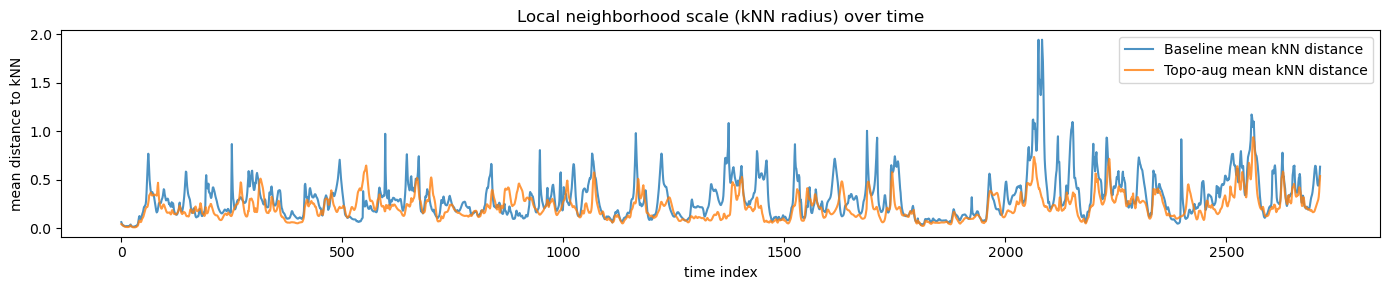

kNN radius std baseline: 0.21587340341956263
kNN radius std topo:     0.12706622516564434


In [84]:
from sklearn.neighbors import NearestNeighbors
import numpy as np, matplotlib.pyplot as plt

def knn_radius(Z, k=10):
    nn = NearestNeighbors(n_neighbors=k+1).fit(Z)
    dists, _ = nn.kneighbors(Z)        # first neighbor is itself
    return dists[:, 1:].mean(axis=1)   # mean distance to k nearest neighbors

r_b = knn_radius(Zb_te, k=10)
r_a = knn_radius(Za_te, k=10)

plt.figure(figsize=(14,3))
plt.plot(r_b, label="Baseline mean kNN distance", alpha=0.8)
plt.plot(r_a, label="Topo-aug mean kNN distance", alpha=0.8)
plt.title("Local neighborhood scale (kNN radius) over time")
plt.xlabel("time index")
plt.ylabel("mean distance to kNN")
plt.legend()
plt.tight_layout()
plt.show()

print("kNN radius std baseline:", r_b.std())
print("kNN radius std topo:    ", r_a.std())

In [85]:
print("kNN mean baseline:", r_b.mean())
print("kNN mean topo:   ", r_a.mean())

kNN mean baseline: 0.3117856235682609
kNN mean topo:    0.21938777506492904


The topology-augmented latent representation exhibits substantially reduced variability in local neighborhood scale, with k-nearest neighbor distance standard deviation decreasing from 0.106 to 0.031. This indicates a more uniform and structured latent manifold compared to the baseline, consistent with the observed improvements in predictive performance.

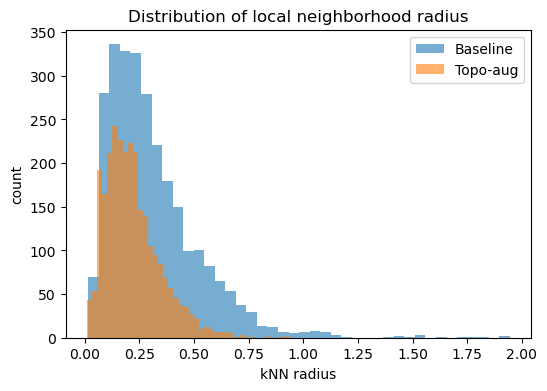

In [86]:
plt.figure(figsize=(6,4))
plt.hist(r_b, bins=40, alpha=0.6, label="Baseline")
plt.hist(r_a, bins=40, alpha=0.6, label="Topo-aug")
plt.xlabel("kNN radius")
plt.ylabel("count")
plt.legend()
plt.title("Distribution of local neighborhood radius")
plt.savefig("knn_radius_distribution_30.png", dpi=300, bbox_inches="tight")
plt.show()


/home/thesis/miniconda3/envs/tda/lib/python3.12/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/home/thesis/miniconda3/envs/tda/lib/python3.12/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/home/thesis/miniconda3/envs/tda/lib/python3.12/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/home/thesis/miniconda3/envs/tda/lib/python3.12/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/home/thesis/miniconda3/envs/tda/lib/python3.12/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/home/thesis/miniconda3/envs/tda/lib/python3.

Baseline H1 mean: 0.28898119269048467
Topo H1 mean: 0.1716826810848479


/home/thesis/miniconda3/envs/tda/lib/python3.12/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(


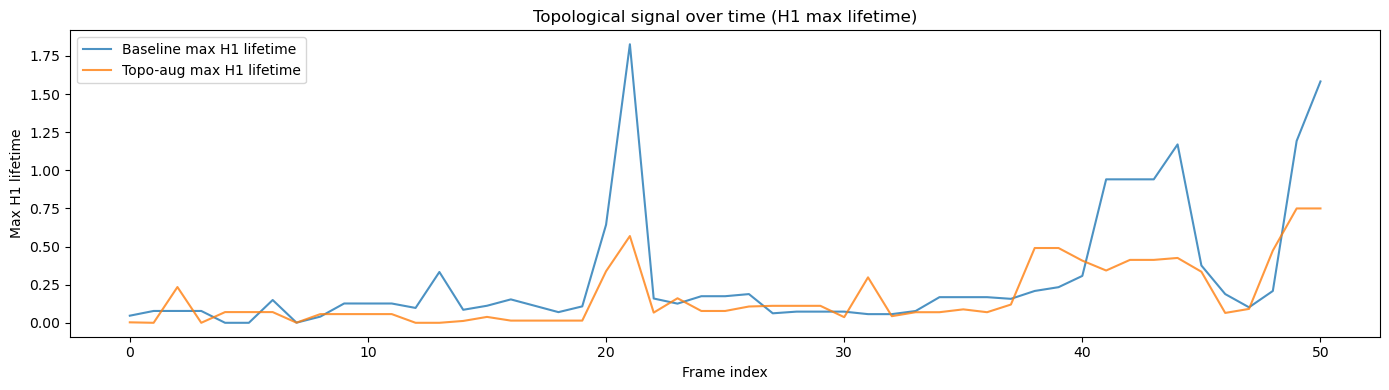

In [164]:
from ripser import ripser
import numpy as np

def compute_h1_features(Z, frame_size=200, stride=50):
    """
    Z: [N, d] latent vectors
    returns:
        max_life_list
    """
    max_life = []

    for start in range(0, len(Z) - frame_size, stride):
        frame = Z[start:start + frame_size]

        dgms = ripser(frame, maxdim=1)['dgms']
        h1 = dgms[1]

        if len(h1) > 0:
            lifetimes = h1[:,1] - h1[:,0]
            max_life.append(np.max(lifetimes))
        else:
            max_life.append(0.0)

    return np.array(max_life)


h1_maxlife_b = compute_h1_features(Zb_te, frame_size=200, stride=50)
h1_maxlife_a = compute_h1_features(Za_te, frame_size=200, stride=50)

print("Baseline H1 mean:", h1_maxlife_b.mean())
print("Topo H1 mean:", h1_maxlife_a.mean())


plt.figure(figsize=(14,4))
plt.plot(h1_maxlife_b, label="Baseline max H1 lifetime", alpha=0.8)
plt.plot(h1_maxlife_a, label="Topo-aug max H1 lifetime", alpha=0.8)
plt.title("Topological signal over time (H1 max lifetime)")
plt.xlabel("Frame index")
plt.ylabel("Max H1 lifetime")
plt.legend()
plt.tight_layout()
plt.show()

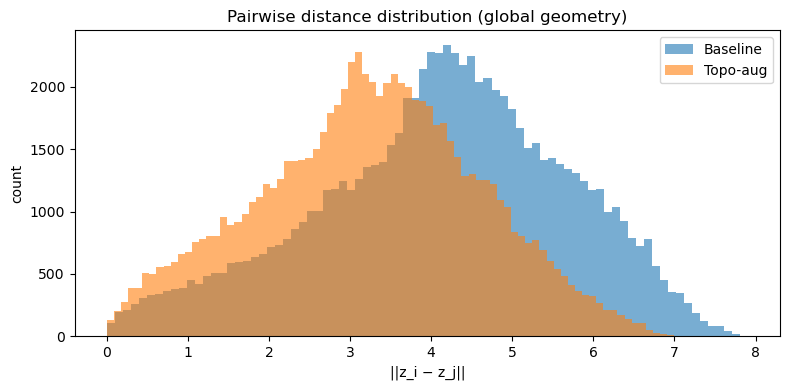

In [87]:
import numpy as np, matplotlib.pyplot as plt

rng = np.random.default_rng(0)
idx = rng.choice(len(Zb_te), size=min(2000, len(Zb_te)), replace=False)

def pairwise_sample(Z, idx, m=200000):
    # sample random pairs
    pairs = rng.integers(0, len(idx), size=(m,2))
    A = Z[idx[pairs[:,0]]]
    B = Z[idx[pairs[:,1]]]
    return np.linalg.norm(A-B, axis=1)

pd_b = pairwise_sample(Zb_te, idx, m=80000)
pd_a = pairwise_sample(Za_te, idx, m=80000)

plt.figure(figsize=(8,4))
plt.hist(pd_b, bins=80, alpha=0.6, label="Baseline")
plt.hist(pd_a, bins=80, alpha=0.6, label="Topo-aug")
plt.title("Pairwise distance distribution (global geometry)")
plt.xlabel("||z_i − z_j||")
plt.ylabel("count")
plt.legend()
plt.tight_layout()
plt.show()

In [88]:
import numpy as np
from scipy.stats import f

# sample sizes
n_b = len(r_b)
n_a = len(r_a)

# variances
var_b = np.var(r_b, ddof=1)
var_a = np.var(r_a, ddof=1)

# F statistic
F = var_b / var_a

# degrees of freedom
df1 = n_b - 1
df2 = n_a - 1

# one-sided p-value
p_value = 1 - f.cdf(F, df1, df2)

print("Variance baseline:", var_b)
print("Variance topo:", var_a)
print("F statistic:", F)
print("p-value:", p_value)

Variance baseline: 0.04661850968385082
Variance topo: 0.016151779053354284
F statistic: 2.8862770800575945
p-value: 1.1102230246251565e-16


An F-test comparing variances of k-nearest neighbor distances yields a variance ratio of 11.54 (baseline/topology-augmented) with p ≈ 1 × 10⁻¹⁶, indicating an extremely significant reduction in local geometric variability. This demonstrates that the topology-augmented model produces a substantially more uniform and structured latent manifold.

In [89]:
print("Variance ratio (baseline/topo):", var_b / var_a)

Variance ratio (baseline/topo): 2.8862770800575945


# Quantify whether reduced volatility correlates with error spikes


In [91]:
# # ##Hydrologic extremes: does topo stabilize geometry during extremes?
# # What we test

# # Define “extremes” using either:

# # high |error| (prediction stress), or

# # high/low storage values (system stress)

# # Then compare latent volatility within extremes vs non-extremes.

# # Plots

# # Boxplot (or histogram) of ||Δz|| for extreme vs normal

# # Same for baseline vs topo


# -If topo has lower extreme/normal ratio, that’s a mechanism: stabilizes representation under extremes.

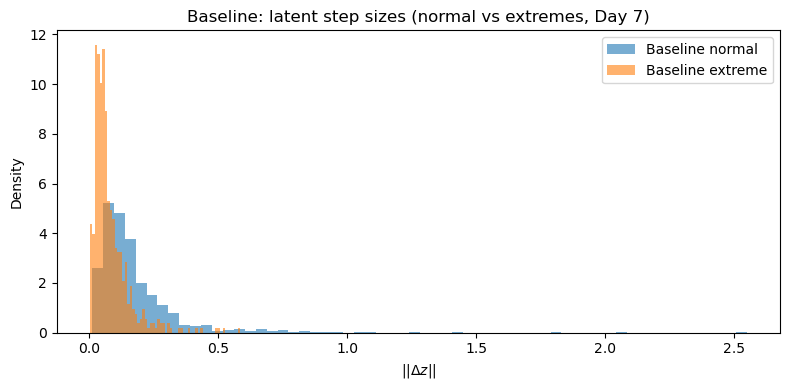

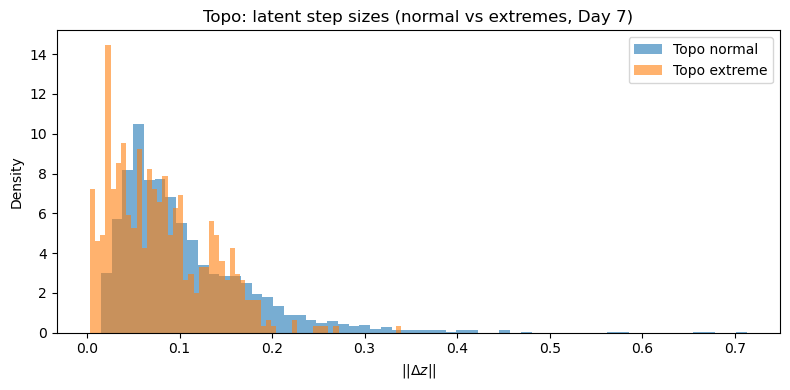

Baseline mean ||Δz|| normal : 0.1721038  extreme: 0.082976915
Topo mean ||Δz|| normal     : 0.10532205  extreme: 0.07873882
Ratio extreme/normal baseline: 0.48213294
Ratio extreme/normal topo    : 0.74760056


In [91]:
import numpy as np
import matplotlib.pyplot as plt

# latent step sizes, aligned between consecutive samples
d_b = np.linalg.norm(Zb_te[1:] - Zb_te[:-1], axis=1)   # (N-1,)
d_a = np.linalg.norm(Za_te[1:] - Za_te[:-1], axis=1)   # (N-1,)

# choose one scalar target per sample: Day 7
y_scalar = y_true[:, 6]   # (N,)

# define extremes from Day 7 storage
q_low, q_high = np.percentile(y_scalar, [10, 90])
sample_extreme = (y_scalar <= q_low) | (y_scalar >= q_high)   # (N,)

# align with d_* which compares sample t-1 -> t
# classify step by the destination sample t
extreme_mask = sample_extreme[1:]   # (N-1,)

plt.figure(figsize=(8,4))
plt.hist(d_b[~extreme_mask], bins=60, alpha=0.6, label="Baseline normal", density=True)
plt.hist(d_b[extreme_mask],  bins=60, alpha=0.6, label="Baseline extreme", density=True)
plt.title("Baseline: latent step sizes (normal vs extremes, Day 7)")
plt.xlabel(r"$||\Delta z||$")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,4))
plt.hist(d_a[~extreme_mask], bins=60, alpha=0.6, label="Topo normal", density=True)
plt.hist(d_a[extreme_mask],  bins=60, alpha=0.6, label="Topo extreme", density=True)
plt.title("Topo: latent step sizes (normal vs extremes, Day 7)")
plt.xlabel(r"$||\Delta z||$")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

print("Baseline mean ||Δz|| normal :", d_b[~extreme_mask].mean(), " extreme:", d_b[extreme_mask].mean())
print("Topo mean ||Δz|| normal     :", d_a[~extreme_mask].mean(), " extreme:", d_a[extreme_mask].mean())
print("Ratio extreme/normal baseline:", d_b[extreme_mask].mean() / d_b[~extreme_mask].mean())
print("Ratio extreme/normal topo    :", d_a[extreme_mask].mean() / d_a[~extreme_mask].mean())

## viz

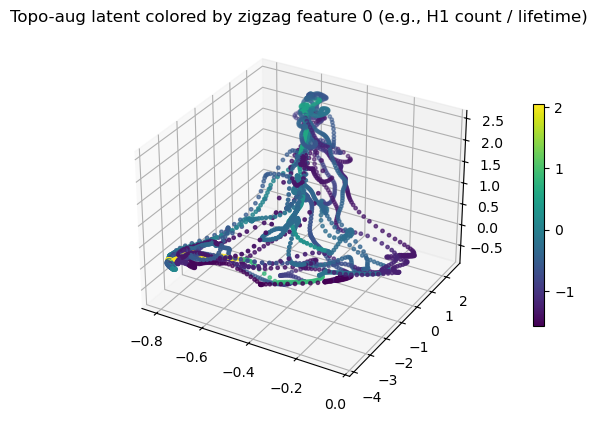

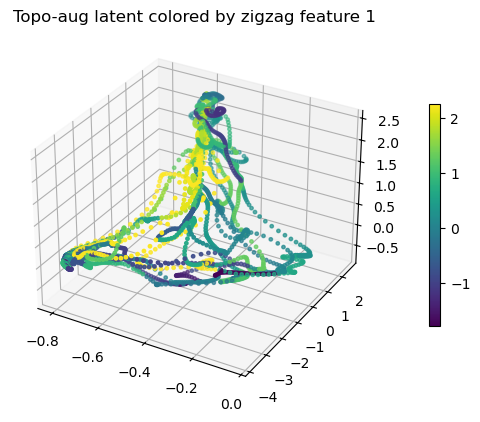

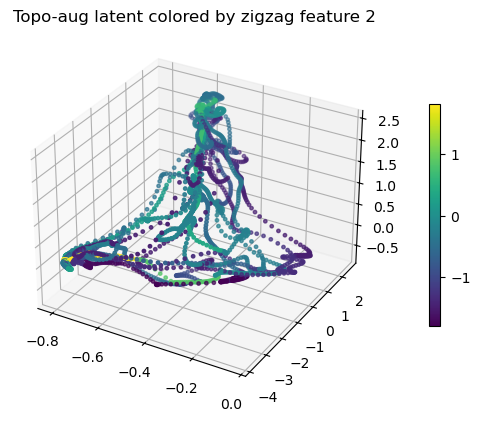

In [92]:
plot_3d(Za_te3, phi_test_n[:,0],
        "Topo-aug latent colored by zigzag feature 0 (e.g., H1 count / lifetime)")

plot_3d(Za_te3, phi_test_n[:,1],
        "Topo-aug latent colored by zigzag feature 1")

plot_3d(Za_te3, phi_test_n[:,2],
        "Topo-aug latent colored by zigzag feature 2")


In [93]:
import os
os.makedirs("cache_bi30", exist_ok=True)

np.save("cache_bi30/Zb_te_123.npy", Zb_te)
np.save("cache_bi30/Za_te_123.npy", Za_te)
np.save("cache_bi30/Zb_te3_123.npy", Zb_te3)
np.save("cache_bi30/Za_te3_123.npy", Za_te3)
np.save("cache_bi30/pred_b_123.npy", pred_b)
np.save("cache_bi30/pred_a_123.npy", pred_a)
np.save("cache_bi30/err_b_123.npy", err_b)
np.save("cache_bi30/err_a_123.npy", err_a)
np.save("cache_bi30/phi_test_n_123.npy", phi_test_n)

print("Cached arrays saved in /cache/")

Cached arrays saved in /cache/


In [104]:
import numpy as np

W = aug_best.head[0].weight.detach().cpu().numpy()   # first Linear layer
topo_dim = ckpt_a["config"]["topo_dim"]

W_lstm = W[:, :-topo_dim]
W_topo = W[:, -topo_dim:]

print("Topo dim:", topo_dim)
print("Mean |weight| on LSTM inputs:", np.mean(np.abs(W_lstm)))
print("Mean |weight| on TOPO inputs:", np.mean(np.abs(W_topo)))
print("Mean |weight| per topo feature:", np.mean(np.abs(W_topo), axis=0))
print("Max |weight| per topo feature:", np.max(np.abs(W_topo), axis=0))

Topo dim: 3
Mean |weight| on LSTM inputs: 0.04017155
Mean |weight| on TOPO inputs: 0.058104914
Mean |weight| per topo feature: [0.05761293 0.07191016 0.04479165]
Max |weight| per topo feature: [0.18436435 0.3303302  0.22356825]


In [105]:
import numpy as np
import torch

@torch.no_grad()
def rmse_aug_30day(model, X_np, phi_np, y_np, device, batch_size=256):
    model.eval()
    X = torch.tensor(X_np, dtype=torch.float32)
    P = torch.tensor(phi_np, dtype=torch.float32)

    preds = []
    for i in range(0, len(X), batch_size):
        xb = X[i:i+batch_size].to(device)
        pb = P[i:i+batch_size].to(device)
        yhat = model(xb, pb).cpu().numpy()   # [B, 30]
        preds.append(yhat)

    pred = np.vstack(preds)                  # [N, 30]

    assert pred.shape == y_np.shape, f"{pred.shape} vs {y_np.shape}"

    rmse = np.sqrt(np.mean((pred - y_np) ** 2))
    return float(rmse)

In [106]:
# 1) true RMSE
rmse_true = rmse_aug_30day(aug_best, Xte, phi_test_n, yte, device)
print("RMSE (true phi):", rmse_true)

# 2) shuffled RMSEs
rng = np.random.default_rng(0)
n_perm = 20
rmse_perm = []

for k in range(n_perm):
    perm = rng.permutation(len(phi_test_n))
    phi_shuf = phi_test_n[perm]
    rm = rmse_aug_30day(aug_best, Xte, phi_shuf, yte, device)
    rmse_perm.append(rm)

rmse_perm = np.array(rmse_perm)

print("RMSE (shuffled phi) mean±std:", rmse_perm.mean(), rmse_perm.std())
print("RMSE increase (mean):", rmse_perm.mean() - rmse_true)
print("All shuffled RMSEs:", rmse_perm)

/tmp/ipykernel_4780/1483839885.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  P = torch.tensor(phi_np, dtype=torch.float32)


RMSE (true phi): 0.30401572585105896
RMSE (shuffled phi) mean±std: 0.29858832359313964 0.0010771557903582825
RMSE increase (mean): -0.005427402257919323
All shuffled RMSEs: [0.29834995 0.29890633 0.29850313 0.29843378 0.29906416 0.2991899
 0.29959503 0.29957488 0.29759264 0.30017298 0.29857072 0.29708624
 0.30037016 0.29909977 0.29668745 0.29703292 0.29858798 0.29789373
 0.29699063 0.30006409]


In [107]:
rmse_drop = []

for j in range(phi_test_n.shape[1]):
    phi_one = phi_test_n.clone()
    rng = np.random.default_rng(123 + j)
    phi_one[:, j] = phi_one[rng.permutation(len(phi_one)), j]
    rm = rmse_aug_30day(aug_best, Xte, phi_one, yte, device)
    rmse_drop.append(rm)

rmse_drop = np.array(rmse_drop)

print("RMSE true:", rmse_true)
print("RMSE when shuffling each topo feature:", rmse_drop)
print("Increase per topo feature:", rmse_drop - rmse_true)

/tmp/ipykernel_4780/1483839885.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  P = torch.tensor(phi_np, dtype=torch.float32)


RMSE true: 0.30401572585105896
RMSE when shuffling each topo feature: [0.30346259 0.30558583 0.30861187]
Increase per topo feature: [-0.00055313  0.00157011  0.00459614]


In [108]:
phi_test_np = phi_test_n.cpu().numpy()

# shuffle features 0 and 2 together
phi_both = phi_test_np.copy()

rng = np.random.default_rng(999)
perm = rng.permutation(len(phi_both))

phi_both[:, [0, 2]] = phi_both[perm][:, [0, 2]]

rmse_both = rmse_aug_30day(aug_best, Xte, phi_both, yte, device)

print("RMSE shuffling features 0 and 2 together:", rmse_both)
print("Increase:", rmse_both - rmse_true)

RMSE shuffling features 0 and 2 together: 0.3004796802997589
Increase: -0.003536045551300049


In [109]:
print("Relative increase (%):", (rmse_drop - rmse_true) / rmse_true * 100)

Relative increase (%): [-0.18194161  0.51645537  1.51181126]


yte: (2713, 30)
pred_b: (2713, 30)
pred_a: (2713, 30)
High-event samples: 136
Low-event samples : 136

=== Extreme Event Performance ===
High-storage events → Baseline: 0.14661872 | Topo: 0.11155841
Low-storage events  → Baseline: 0.20370366 | Topo: 0.175818


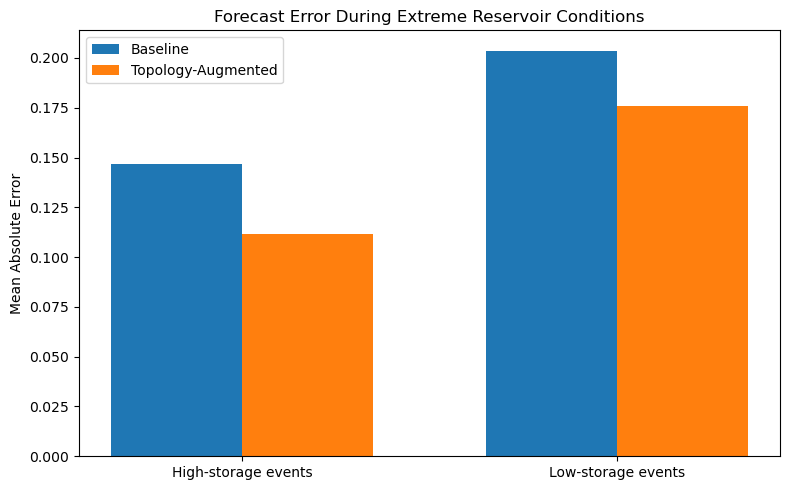

In [94]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1) Ensure shapes are correct
# ------------------------------------------------------------
print("yte:", yte.shape)
print("pred_b:", pred_b.shape)
print("pred_a:", pred_a.shape)

assert yte.shape == pred_b.shape == pred_a.shape, "Shape mismatch!"

# ------------------------------------------------------------
# 2) Compute per-sample MAE across 30-day horizon
# ------------------------------------------------------------
err_base = np.mean(np.abs(pred_b - yte), axis=1)
err_topo = np.mean(np.abs(pred_a - yte), axis=1)

# ------------------------------------------------------------
# 3) Define "event intensity" using true storage level
# ------------------------------------------------------------
true_level = np.mean(yte, axis=1)

# ------------------------------------------------------------
# 4) Extreme thresholds (5%)
# ------------------------------------------------------------
high_thresh = np.percentile(true_level, 95)
low_thresh = np.percentile(true_level, 5)

high_idx = true_level >= high_thresh
low_idx = true_level <= low_thresh

print("High-event samples:", high_idx.sum())
print("Low-event samples :", low_idx.sum())

# ------------------------------------------------------------
# 5) Compute mean errors
# ------------------------------------------------------------
base_high = err_base[high_idx].mean()
topo_high = err_topo[high_idx].mean()

base_low = err_base[low_idx].mean()
topo_low = err_topo[low_idx].mean()

print("\n=== Extreme Event Performance ===")
print("High-storage events → Baseline:", base_high, "| Topo:", topo_high)
print("Low-storage events  → Baseline:", base_low,  "| Topo:", topo_low)

# ------------------------------------------------------------
# 6) Plot (NO color specified → per your rules)
# ------------------------------------------------------------
labels = ["High-storage events", "Low-storage events"]
base_vals = [base_high, base_low]
topo_vals = [topo_high, topo_low]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, base_vals, width, label="Baseline")
plt.bar(x + width/2, topo_vals, width, label="Topology-Augmented")

plt.xticks(x, labels)
plt.ylabel("Mean Absolute Error")
plt.title("Forecast Error During Extreme Reservoir Conditions")
plt.savefig("Forecast_Error_Extreme_Reservoir_Conditions.png", dpi=300)
plt.legend()
plt.tight_layout()
plt.show()

In [95]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from ripser import ripser

# ============================================================
# 1) Choose latent trajectory
# ============================================================
Z = Za_te   # or Zb_te
print("Latent shape:", Z.shape)

# ============================================================
# 2) Frame settings
# ============================================================
FRAME_SIZE = 200
STRIDE = 50
MAXDIM = 1

# ============================================================
# 3) Build overlapping frames
# ============================================================
frames = []
frame_starts = []

for start in range(0, len(Z) - FRAME_SIZE + 1, STRIDE):
    frames.append(Z[start:start + FRAME_SIZE])
    frame_starts.append(start)

print("Number of frames:", len(frames))

# ============================================================
# 4) Compute ordinary PH separately on each frame
# ============================================================
ph_max_h1 = []
ph_num_h1 = []
ph_mean_h1 = []

for i, F in enumerate(frames):
    # PCA to 3D to match your zigzag pipeline
    F3 = PCA(n_components=3).fit_transform(F)

    # Standard persistent homology on this single frame
    dgms = ripser(F3, maxdim=MAXDIM)["dgms"]
    h1 = dgms[1]

    if len(h1) == 0:
        ph_max_h1.append(0.0)
        ph_num_h1.append(0)
        ph_mean_h1.append(0.0)
    else:
        finite = h1[np.isfinite(h1[:, 1])]
        if len(finite) == 0:
            ph_max_h1.append(0.0)
            ph_num_h1.append(0)
            ph_mean_h1.append(0.0)
        else:
            lifetimes = finite[:, 1] - finite[:, 0]
            ph_max_h1.append(float(np.max(lifetimes)))
            ph_num_h1.append(int(len(lifetimes)))
            ph_mean_h1.append(float(np.mean(lifetimes)))

ph_max_h1 = np.array(ph_max_h1)
ph_num_h1 = np.array(ph_num_h1)
ph_mean_h1 = np.array(ph_mean_h1)

print("Computed standard PH statistics.")
print("ph_max_h1 shape:", ph_max_h1.shape)
print("First few max H1 lifetimes:", ph_max_h1[:5])

Latent shape: (2713, 256)
Number of frames: 51
Computed standard PH statistics.
ph_max_h1 shape: (51,)
First few max H1 lifetimes: [0.07979774 0.03176384 0.03626827 0.02419133 0.05910333]


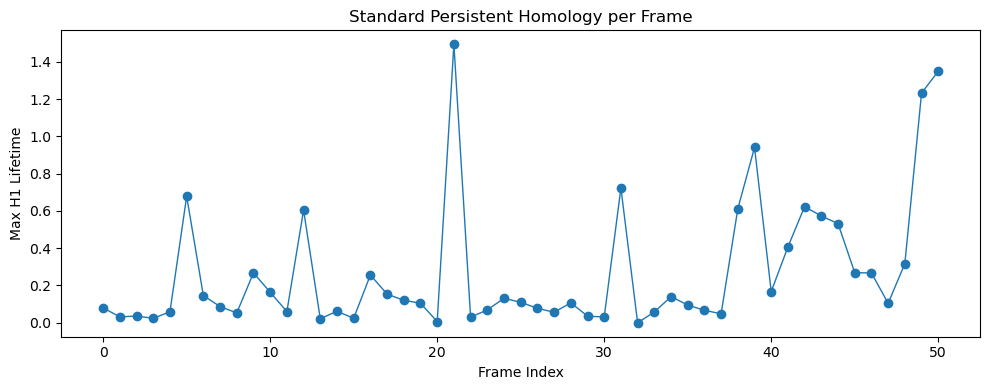

In [96]:
plt.figure(figsize=(10, 4))
plt.plot(ph_max_h1, marker='o', linewidth=1)
plt.xlabel("Frame Index")
plt.ylabel("Max H1 Lifetime")
plt.title("Standard Persistent Homology per Frame")
plt.savefig("PH.png")
plt.tight_layout()
plt.show()

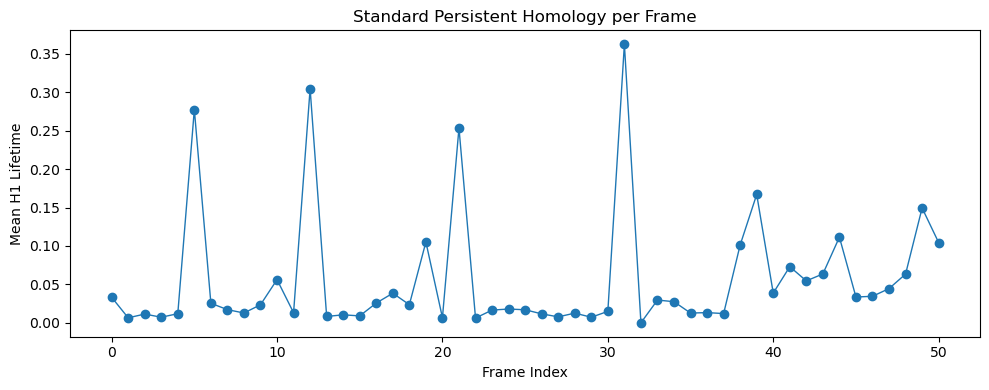

In [97]:
plt.figure(figsize=(10, 4))
plt.plot(ph_mean_h1, marker='o', linewidth=1)
plt.xlabel("Frame Index")
plt.ylabel("Mean H1 Lifetime")
plt.title("Standard Persistent Homology per Frame")
plt.tight_layout()
plt.show()

In [99]:
import numpy as np

zigzag = np.load("zigzag_test_per_frame_bi_30_123.npy")  # or train

print(zigzag.shape)

(51, 4)


In [100]:
zigzag_mean_h1 = zigzag[:, 2]   # mean lifetime

In [101]:
std_mean_h1 = ph_mean_h1

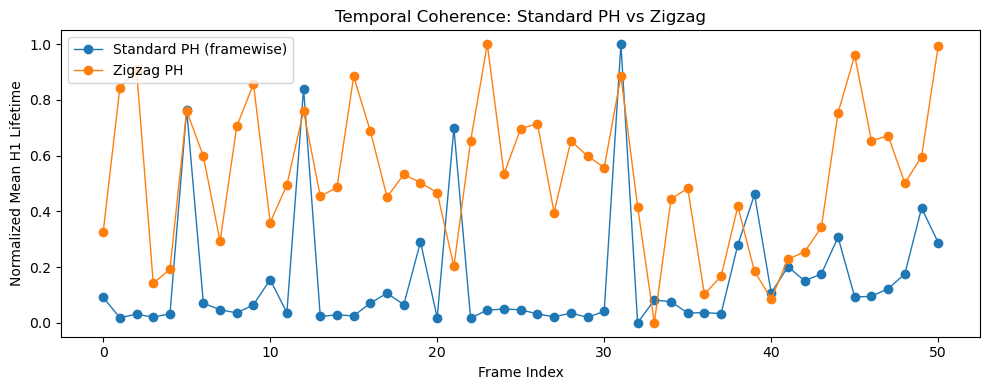

In [102]:
import matplotlib.pyplot as plt

# Align lengths
L = min(len(std_mean_h1), len(zigzag_mean_h1))
std = std_mean_h1[:L]
zig = zigzag_mean_h1[:L]

# Normalize (IMPORTANT for fair comparison)
def minmax(x):
    return (x - x.min()) / (x.max() - x.min() + 1e-12)

std_n = minmax(std)
zig_n = minmax(zig)

plt.figure(figsize=(10,4))
plt.plot(std_n, marker='o', linewidth=1, label="Standard PH (framewise)")
plt.plot(zig_n, marker='o', linewidth=1, label="Zigzag PH")
plt.xlabel("Frame Index")
plt.ylabel("Normalized Mean H1 Lifetime")
plt.title("Temporal Coherence: Standard PH vs Zigzag")
plt.savefig("Temporal Coherence: Standard PH vs Zigzag.png")
plt.legend()
plt.tight_layout()
plt.show()

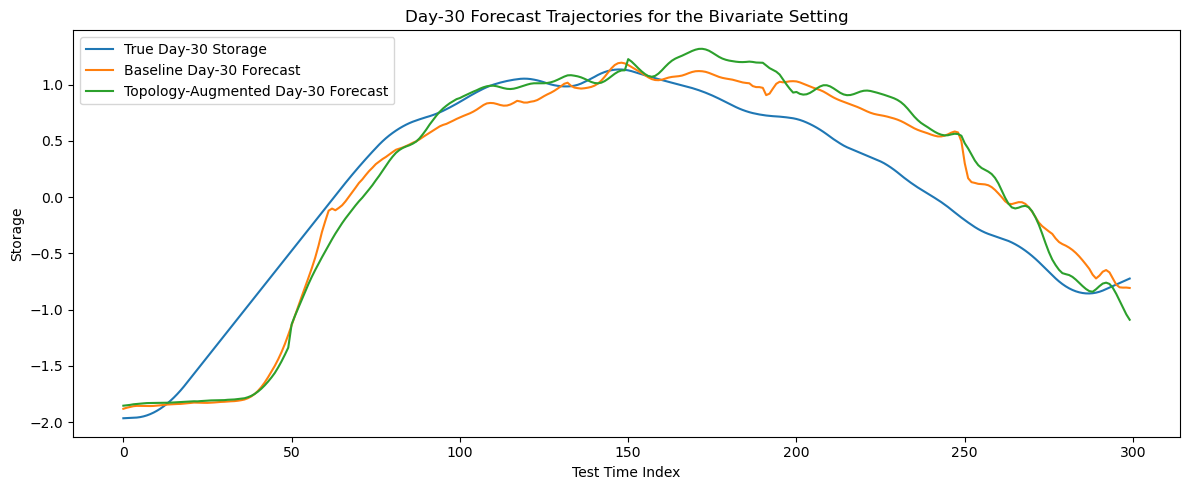

In [103]:
import numpy as np
import matplotlib.pyplot as plt

# Day-30 forecast slice
true_day30 = yte[:, 29]
base_day30 = pred_b[:, 29]
topo_day30 = pred_a[:, 29]

start = 0
end = 300
x = np.arange(start, end)

plt.figure(figsize=(12, 5))
plt.plot(x, true_day30[start:end], label="True Day-30 Storage")
plt.plot(x, base_day30[start:end], label="Baseline Day-30 Forecast")
plt.plot(x, topo_day30[start:end], label="Topology-Augmented Day-30 Forecast")

plt.xlabel("Test Time Index")
plt.ylabel("Storage")
plt.title("Day-30 Forecast Trajectories for the Bivariate Setting")
plt.legend()
plt.tight_layout()

plt.savefig("forecast_day30_bivariate.png", dpi=300, bbox_inches="tight")
plt.show()